# **Automated Analysis Pipeline Notebook**
## Diabetes Prediction and Automated Analysis

**Student Name:** `Vannie Nguyen`

---

**Dataset:** Pima Indians Diabetes Database (NIH–NIDDK)

**Description:** This dataset contains diagnostic measurements from women aged 21 years or older of Pima Indian heritage. The binary prediction task is to classify whether a patient has diabetes based on the available predictor variables.

**Notebook Purpose:** Demonstrate data exploration, inferential statistics, and automated machine learning workflows, including data ingestion, missing-value handling, preprocessing, model training, and evaluation.

**Note:** This dataset is used for instructional and demonstration purposes only.

### **Assignment Description**

The purpose of the Automated Analysis Pipeline Exploration assignment is to strengthen students' understanding of how structured, reproducible, and adaptive analytical workflows are developed in health data science. Students will execute, examine, and modify a provided automated analysis pipeline to explore how foundational programming concepts, conditional logic, data exploration, and analytical decision-making work together to support automated analyses. This assignment emphasizes analytical reasoning, workflow organization, code readability, reproducibility, and the practical integration of statistical and machine learning methods within a health data science context.

Your task is to implement and execute **at least four additional examples of automated analysis code** in Google Colab beyond those provided. Examine how your workflow responds to dataset characteristics and user-defined goals. Identify the conditional logic used to automate decisions, explain the purpose of each pipeline stage, interpret the outputs (as needed), and modify selected workflow components to demonstrate how those changes affect the analysis. The links below jump to the corresponding code blocks within your copy of the notebook.

**Examples:**
1. **[Automated data ingestion](#scrollTo=OVaf3I1zyE70):** Identifies the file format and uses conditional logic to automatically select the appropriate method for reading and loading the data.

2. **Automated identification and reporting of invalid and missing values:** This process uses two consecutive blocks:
   - **[Identify known impossible values for later imputation](#scrollTo=_1r0rJ1BCX2v):** Uses a predefined list of variables to automatically replace known invalid zeros with missing values. The variable list requires knowledge of the dataset.
   - **[Automatically identify missing values in numeric predictors](#scrollTo=njK9LR0r3c7U):** Automatically identifies numeric predictors and reports their missing-value counts, including missing values created by the preceding block.

   These blocks prepare and inspect the data. Later, the machine learning pipeline fills missing predictors using medians learned from the training set and applies those same medians to the test set.

3. **[Configure and split data for the automated ML pipeline](#scrollTo=0aiR0U5sCiM-):** Uses the specified outcome variable to automatically separate predictors from the outcome, exclude rows with missing outcomes, check for numeric predictors and a binary outcome coded 0/1, and split the data into 70% training and 30% testing while preserving class proportions.

4. **[Automatically preprocess, train, and evaluate ML models](#scrollTo=l7Vt_M-pCpq0):** Automatically fills missing predictors using training-set medians, scales predictors for logistic regression, and trains logistic regression and decision tree models. Evaluates both models on the same test set, displays confusion matrices, and generates a comparison table with accuracy, recall, precision, F1, and ROC AUC scores.

In [1]:
# @title **Upload your dataset**

from google.colab import files
import pandas as pd
import io
from pathlib import Path

uploaded = files.upload()

if len(uploaded) != 1:
    raise ValueError("Please upload exactly one data file.")

filename = next(iter(uploaded))
extension = Path(filename).suffix.lower()
file_data = io.BytesIO(uploaded[filename])

if extension in [".csv", ".tsv", ".txt"]:
    # Automatically detect the delimiter.
    df = pd.read_csv(file_data, sep=None, engine="python")

elif extension in [".xlsx", ".xls"]:
    # Load the first worksheet.
    df = pd.read_excel(file_data)

elif extension == ".json":
    df = pd.read_json(file_data)

elif extension == ".parquet":
    df = pd.read_parquet(file_data)

else:
    raise ValueError(
        f"'{extension}' files require a different reader. "
        "Supported formats: CSV, TSV, TXT, XLSX, XLS, JSON, and Parquet."
    )

print(f"Successfully loaded: {filename}")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

display(df.head())

Saving Pima Indians diabetes dataset (PIDD).xlsx to Pima Indians diabetes dataset (PIDD) (1).xlsx
Successfully loaded: Pima Indians diabetes dataset (PIDD) (1).xlsx
Rows: 768 | Columns: 9


,Pregnancies,Glucose,Blood pressure,Skin thickness,Insulin,Body mass index,Diabetes pedigree function,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# @title **View first 10 rows of data**

df.head(20) # CHANGE NUMBER TO INCREASE OR DECREASE THE NUMBER OF ROWS

,Pregnancies,Glucose,Blood pressure,Skin thickness,Insulin,Body mass index,Diabetes pedigree function,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
# @title **View a list of all variables**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
attribute_list = list(df.columns)
print("Variables in the dataset:")
print("")
print(attribute_list)

Variables in the dataset:

['Pregnancies', 'Glucose', 'Blood pressure', 'Skin thickness', 'Insulin', 'Body mass index', 'Diabetes pedigree function', 'Age', 'Outcome']


In [4]:
# @title **View the number of rows and columns in the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
print("Number of rows and columns:")
print("")
df.shape   # (rows, columns)

Number of rows and columns:



(768, 9)

In [5]:
# @title **View general information about the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pregnancies                 768 non-null    int64  
 1   Glucose                     768 non-null    int64  
 2   Blood pressure              768 non-null    int64  
 3   Skin thickness              768 non-null    int64  
 4   Insulin                     768 non-null    int64  
 5   Body mass index             768 non-null    float64
 6   Diabetes pedigree function  768 non-null    float64
 7   Age                         768 non-null    int64  
 8   Outcome                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


***Interpretation***: The dataset contains 768 observations and 9 numeric variables. There are no conventional missing values (NaN), and all variables are stored as either integer or floating-point numeric data types. The 'Outcome' variable represents the diabetes outcome and can be used as the target variable for supervise machine learning. Although there are no null values, some clinical variables may contain zero values that could represent missing or invalid measurements, so these values should be evaluated during data preprocessing.

In [6]:
# @title **Describe the data (and data type) for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Describe all columns
summary = df.describe(include='all').T

# Replace NaN values with 'NA'
summary = summary.fillna('NA')

# Insert formatted variable name + data type
summary.insert(
    0,
    'Variable',
    [f"<b>{col}</b><br><span style='font-weight:normal; font-size:smaller;'>[{df[col].dtype}]</span>" for col in summary.index]
)

# Reset index to clean up formatting
summary.reset_index(drop=True, inplace=True)

# Format numeric columns to 3 decimal places only
styled_summary = (
    summary.style
    .format(precision=3, na_rep="NA")  # Format numbers to 3 decimals
    .set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
    .hide(axis='index')  # Remove default row index
)

styled_summary

Variable,count,mean,std,min,25%,50%,75%,max
Pregnancies[int64],768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose[int64],768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
Blood pressure[int64],768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
Skin thickness[int64],768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin[int64],768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
Body mass index[float64],768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
Diabetes pedigree function[float64],768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age[int64],768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome[int64],768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


***Interpretation***

The average number of pregnancies was 3.845, with a median of 3 and a range from 0 to 17. The mean glucose level was 120.895, while the median was 117. Blood pressure had a mean of 69.105 and a median of 72. Several clinical variables, including glucose, blood pressure, skin thickness, insulin, and BMI, had minimum values of 0. Since zero is not physiologically plausible for some of these measurements, these values may represent missing or improperly recorded observations rather than true measurements.

The 'Outcome' variable had a mean of 0.349. As this is a binary variable coded as 0 and 1, the mean indicates that approximately 34.9% of observations had an outcome of 1, while approximately 65.1% had an outcome of 0. This indicates some class imbalance, although both outcome categories are sufficiently represented.

The descriptive statistics indicate that the dataset contains entirely numeric variables and a binary outcome, making it appropriate for supervised classification analysis. However, the zero values found in several clinical variables should be examined during preprocessing because they may represent missing or invalid measurements. These characteristics can influence subsequent decisions made by the automated analysis pipeline.

In [7]:
# @title **Identify known impossible values for later imputation**

import numpy as np

variables_to_replace_zeros = [
    'Glucose', 'Blood pressure', 'Skin thickness', 'Insulin', 'Body mass index'
]

for variable in variables_to_replace_zeros:
    if variable in df.columns:
        df[variable] = df[variable].replace(0, np.nan)

print("Impossible zeros replaced with missing values.")
print("The ML pipeline will impute missing predictors using training data.")

Impossible zeros replaced with missing values.
The ML pipeline will impute missing predictors using training data.


In [8]:
# @title **Automatically identify other missing values in numeric predictors**

target_variable = "Outcome"

# Automatically identify numeric predictors.
numeric_predictors = df.select_dtypes(include="number").columns
numeric_predictors = numeric_predictors.drop(
    target_variable, errors="ignore"
)

# Count missing values.
missing_counts = df[numeric_predictors].isna().sum()
predictors_with_missing = missing_counts[missing_counts > 0]

if predictors_with_missing.empty:
    print("No missing values detected in numeric predictors.")
else:
    print("Predictors requiring imputation:")
    display(predictors_with_missing.rename("Missing values").to_frame())
    print("Block #4 will automatically fill these using training-set medians.")

Predictors requiring imputation:


,Missing values
Glucose,5
Blood pressure,35
Skin thickness,227
Insulin,374
Body mass index,11


Block #4 will automatically fill these using training-set medians.


***Interpretation***


After replacing the impossible zero values with missing values, the pipeline identified five predictors that need imputation: Glucose, blood pressure, skin thickness, insulin, and BMI. Glucose had 5 missing values, blood pressure had 35, skin thickness had 227, insulin had 374, and BMI had 11 missing values.

Insulin had the most missing values, with 374 out of 768 observations, which is about 48.7% of the dataset. Skin thickness had the second highest amount of missing values. The other three variables had much fewer missing values. This is important to notice because having almost half of the insulin values missing could affect the analysis if the missing values were not handled properly.

This steps shows how the pipeline responds to the actual characteristics of the dataset. Instead of assuming that there are no missing values, it checks the predictors and identifies which ones need to be handled before the models are trained.

In [9]:
# @title **Description of just one variable**

# Define the variable name (this can be dynamic)
BMI = 'Body mass index'  # CHANGE VARIABLE HERE


#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Print the title dynamically
print(f"Quantitative Description of {BMI}:")
print("")

# Get the description and round it to 3 decimal places
description = df[BMI].describe().round(3)

# Print the rounded description
print(description)

Quantitative Description of Body mass index:

count    757.000
mean      32.457
std        6.925
min       18.200
25%       27.500
50%       32.300
75%       36.600
max       67.100
Name: Body mass index, dtype: float64


In [10]:
# Define the variable name (this can be dynamic)
Insulin = 'Insulin'  # CHANGE VARIABLE HERE


#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Print the title dynamically
print(f"Quantitative Description of {Insulin}:")
print("")

# Get the description and round it to 3 decimal places
description = df[Insulin].describe().round(3)

# Print the rounded description
print(description)

Quantitative Description of Insulin:

count    394.000
mean     155.548
std      118.776
min       14.000
25%       76.250
50%      125.000
75%      190.000
max      846.000
Name: Insulin, dtype: float64


In [11]:
# @title **Number of responses and missing values for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Count non-null and missing responses
response_counts = df.count()
missing_counts = df.isnull().sum()

# Combine into one DataFrame
df_count = pd.DataFrame({
    'Variable': response_counts.index,
    '# of Responses': response_counts.values,
    '# Missing': missing_counts.values
})

# Display as styled table: bold headers and center-aligned values
df_count.style.set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])

,Variable,# of Responses,# Missing
0,Pregnancies,768,0
1,Glucose,763,5
2,Blood pressure,733,35
3,Skin thickness,541,227
4,Insulin,394,374
5,Body mass index,757,11
6,Diabetes pedigree function,768,0
7,Age,768,0
8,Outcome,768,0


***Interpretation***
This output further confirms that zero values in the selected clinical variables were correctly recognized as missing values. For example, BMI now has 11 missing values and insulin has 374 missing values instead of being treated as actual measurements of zero. The data therefore looks more reasonable for analysis, while the missing values can be handled by the pipeline's imputation step before modeling.

In [12]:
# @title **View 15 random rows of data**
np.random.seed()
df.sample(n=20) # CHANGE NUMBER HERE TO INCREASE OR DECREASE NUMBER OF RANDOM ROWS

,Pregnancies,Glucose,Blood pressure,Skin thickness,Insulin,Body mass index,Diabetes pedigree function,Age,Outcome
401,6,137.0,61.0,NaN,NaN,24.2,0.151,55,0
345,8,126.0,88.0,36.0,108.0,38.5,0.349,49,0
76,7,62.0,78.0,NaN,NaN,32.6,0.391,41,0
674,8,91.0,82.0,NaN,NaN,35.6,0.587,68,0
435,0,141.0,NaN,NaN,NaN,42.4,0.205,29,1
74,1,79.0,75.0,30.0,NaN,32.0,0.396,22,0
551,3,84.0,68.0,30.0,106.0,31.9,0.591,25,0
235,4,171.0,72.0,NaN,NaN,43.6,0.479,26,1
254,12,92.0,62.0,7.0,258.0,27.6,0.926,44,1
748,3,187.0,70.0,22.0,200.0,36.4,0.408,36,1


In [13]:
# @title **Change a variable's data type (e.g., from integer to category)**

# Choose variable to change
variable_to_change = 'Outcome' # CHANGE THIS VARIABLE
new_data_type = 'category' # CHANGE THIS TO THE NEW DATA TYPE (options include category, int64, float)

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
# Capture original data type
original_dtype = df[variable_to_change].dtype

# Change data type (options include category, float, int64)
df[variable_to_change] = df[variable_to_change].astype(new_data_type)

# Capture new data type
new_dtype = df[variable_to_change].dtype

# Print result dynamically
print(f"'{variable_to_change}' variable changed from {original_dtype} to {new_dtype}")
print("")
print("Note: You can revise the code to change the data type for a different variable.")

'Outcome' variable changed from int64 to category

Note: You can revise the code to change the data type for a different variable.


In [14]:
# Choose variable to change
variable_to_change2 = 'Age' # CHANGE THIS VARIABLE
new_data_type2 = 'float'

# Capture original data type
original_dtype2 = df[variable_to_change2].dtype

# Change data type (options include category, float, int64)
df[variable_to_change2] = df[variable_to_change2].astype(new_data_type2)

# Capture new data type
new_dtype2 = df[variable_to_change2].dtype

# Print result dynamically
print(f"'{variable_to_change2}' variable changed from {original_dtype2} to {new_dtype2}")

'Age' variable changed from int64 to float64


I used Age as a practice example to change a variable's data type from integer to float. This helped me understand how the pipeline can be modified to change how variables are stored and handled in the analysis.

## **Exploratory Data Analysis**

In [15]:
# @title **Pearson's correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.corr()

,Pregnancies,Glucose,Blood pressure,Skin thickness,Insulin,Body mass index,Diabetes pedigree function,Age,Outcome
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341,0.221898
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136,0.494650
Blood pressure,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107,0.170589
Skin thickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816,0.259491
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
Body mass index,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841,0.313680
Diabetes pedigree function,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561,0.173844
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000,0.238356
Outcome,0.221898,0.494650,0.170589,0.259491,0.303454,0.313680,0.173844,0.238356,1.000000


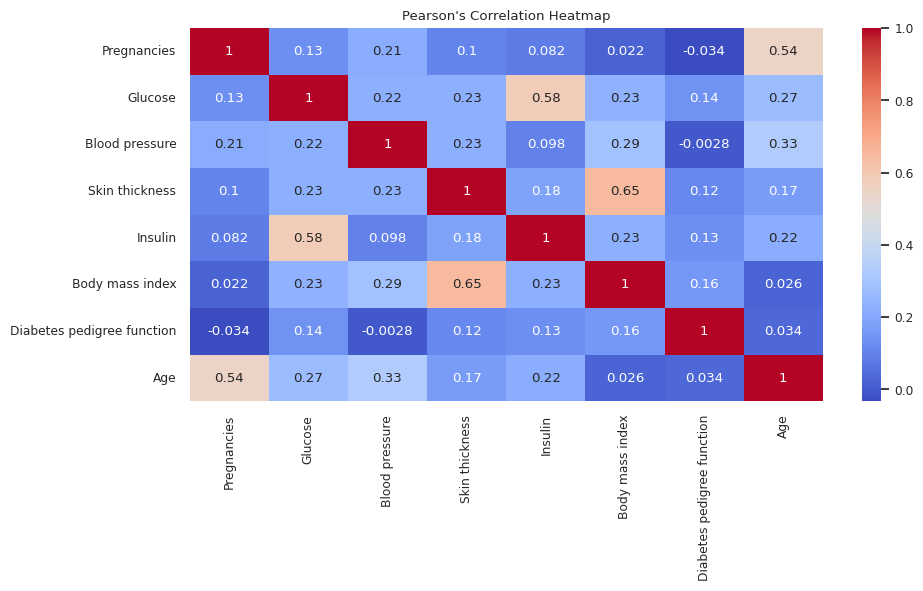

In [16]:
# @title **Pearson's correlation heatmap**

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Pearson's Correlation Heatmap")
plt.tight_layout()
plt.show()

***Interpretation***

The correlation heatmap shows that most variables have relatively weak linear relationships with each other. Glucose has the strongest positive correlation with the diabetes outcome (r=0.47), followed by BMI (r=0.29), Age (r=0.24), and Pregnancies (r=0.22). This suggests that higher values of these variables tend to be associated with a higher likelihood of a positive diabetes outcome.

Some predictors are also correlated with each other, with the strongest relationship being between Pregnancies and Age (r = 0.54). Overall, the correlations are not extremely high, so there do not appear to be obvious strong relationships between predictors based on this heatmap alone.

In [17]:
# @title **Spearman's Rank correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.corr(method='spearman')

,Pregnancies,Glucose,Blood pressure,Skin thickness,Insulin,Body mass index,Diabetes pedigree function,Age,Outcome
Pregnancies,1.000000,0.129547,0.194103,0.086734,0.127859,0.000279,-0.043242,0.607216,0.198689
Glucose,0.129547,1.000000,0.249415,0.229815,0.658813,0.227761,0.090596,0.283315,0.483364
Blood pressure,0.194103,0.249415,1.000000,0.248017,0.130463,0.299176,0.008511,0.370609,0.177227
Skin thickness,0.086734,0.229815,0.248017,1.000000,0.245188,0.685380,0.074979,0.231132,0.265397
Insulin,0.127859,0.658813,0.130463,0.245188,1.000000,0.303515,0.130262,0.267437,0.377300
Body mass index,0.000279,0.227761,0.299176,0.685380,0.303515,1.000000,0.136138,0.121119,0.309324
Diabetes pedigree function,-0.043242,0.090596,0.008511,0.074979,0.130262,0.136138,1.000000,0.042909,0.175353
Age,0.607216,0.283315,0.370609,0.231132,0.267437,0.121119,0.042909,1.000000,0.309040
Outcome,0.198689,0.483364,0.177227,0.265397,0.377300,0.309324,0.175353,0.309040,1.000000


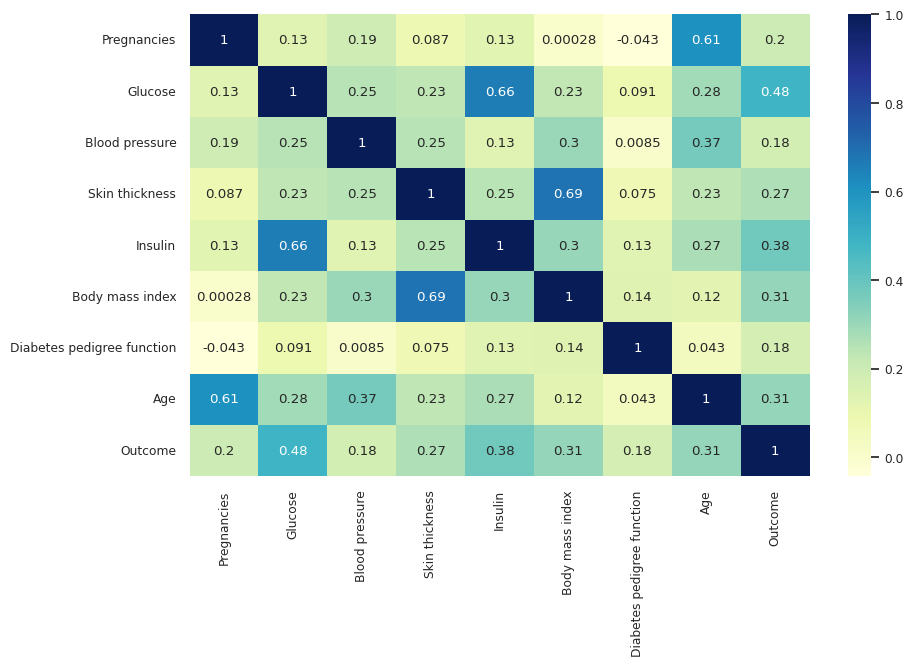

In [18]:
# @title **Spearman's Rank correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5
sns.heatmap(df.corr(method='spearman'), annot=True, cmap="YlGnBu");

***Interpretation***

The Spearman correlation results show a similar overall pattern to the Pearson correlations. Glucose has the strongest positive relationship with Outcome (r=0.48), followed by BMI and Age (both around r = 0.31). Pregnancies and diabetes pedigree function have weaker positive relationships with Outcome. Among the predictors, Pregnancies and Age have the strongest correlation (r = 0.61). Overall, the Spearman results are fairly consistent with the Pearson results, suggesting that the main relationships in the dataset are not substantially different when using ranked rather than linear correlations.

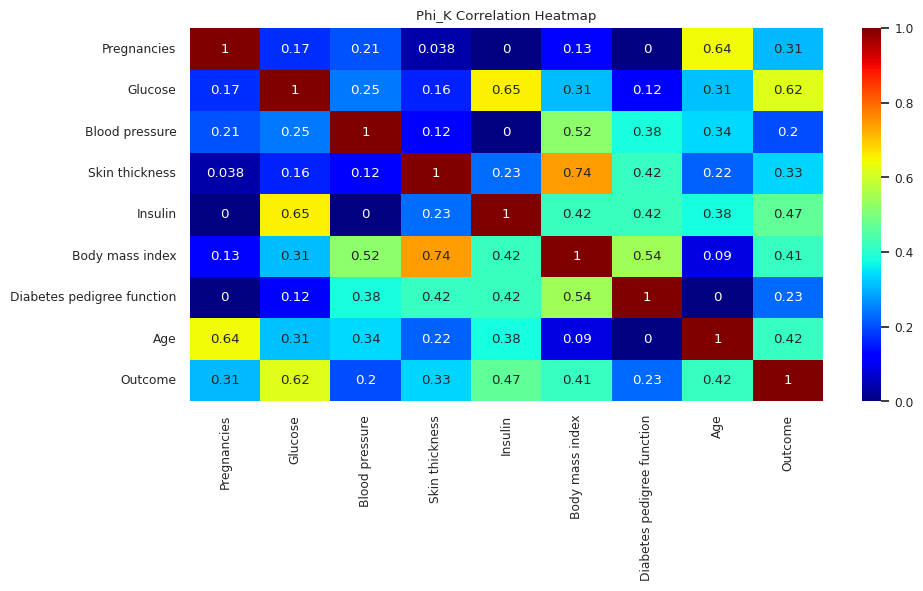

In [19]:
# @title **Phi-K correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

import os
import sys
import subprocess

# Suppress pip install output
subprocess.run([sys.executable, "-m", "pip", "install", "phik"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import phik
from phik import resources, report
from phik.report import plot_correlation_matrix
from phik import phik_matrix

# Identify interval (numerical) columns
interval_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create correlation map using Phi-K
plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

# Compute and plot Phi-K correlation matrix with interval columns specified
phik_corr = df.phik_matrix(interval_cols=interval_cols)
sns.heatmap(phik_corr, annot=True, cmap="jet")

plt.title("Phi_K Correlation Heatmap")
plt.tight_layout()
plt.show()

***Interpretation***

The Phi-K correlation results show that Glucose has the strongest association with Outcome (0.49), followed by Age (0.42), BMI (0.32), and Pregnancies (0.31). This is generally consistent with the Pearson and Spearman results, where Glucose was also the strongest variable associated with Outcome. However, the stronger Phi-K value for Age suggests that its relationship with Outcome may not be fully captured by a simple linear correlation. The results provide another way to examine the relationships between the variables before moving into the modeling portion of the analysis.

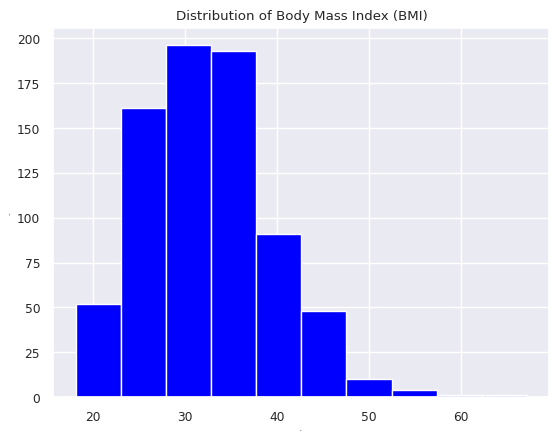

In [20]:
# @title **Example of a histogram**
plt.hist(df['Body mass index'], color='blue') # CHANGE VARIABLE HERE
plt.title('Distribution of Body Mass Index (BMI)')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

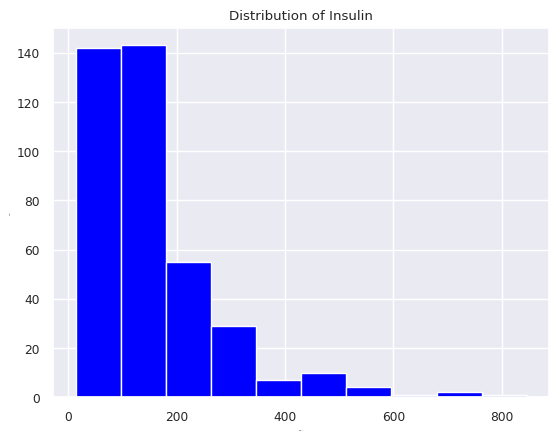

In [21]:
plt.hist(df['Insulin'], color='blue')
plt.title('Distribution of Insulin')
plt.xlabel('Insulin')
plt.ylabel('Count')
plt.show()

***Interpretation***

**BMI** - The BMI histogram shows that most observations are concentrated around 25-40, with the highest number of observations around 30-35. There are fewer observations at the lower and higher ends of the distribution. The distribution has a right skew, with a longer tail toward higher BMI values.

**Insulin** - The insulin histogram is much more right-skewed. Most observations are concentrated at the lower values, particularly below about 200, while a smaller number of observations extend to much higher values, reaching above 800. This indicates that insulin has a wide range and some unusually high values.

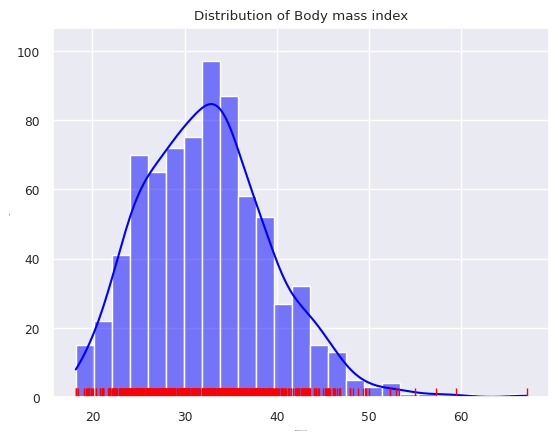

In [22]:
# @title **Example of a distribution plot**

import seaborn as sns
import matplotlib.pyplot as plt

variable = "Body mass index"

sns.histplot(data=df, x=variable, color="blue", kde=True)
sns.rugplot(data=df, x=variable, color="red")

plt.title(f"Distribution of {variable}")
plt.show()

***Interpretation***

Similar to the previous interpretation, the BMI distribution is concentrated mostly between about 25 and 40, with the highest concentration around 30-35. The curve shows a similar patter, with the distribution peaking around the mid 30s and gradually decreasing at higher BMI values. The red rug marks show the individual observations and also show that fewer observations occur at the higher BMI values. The distribution is slightly right-skewed.

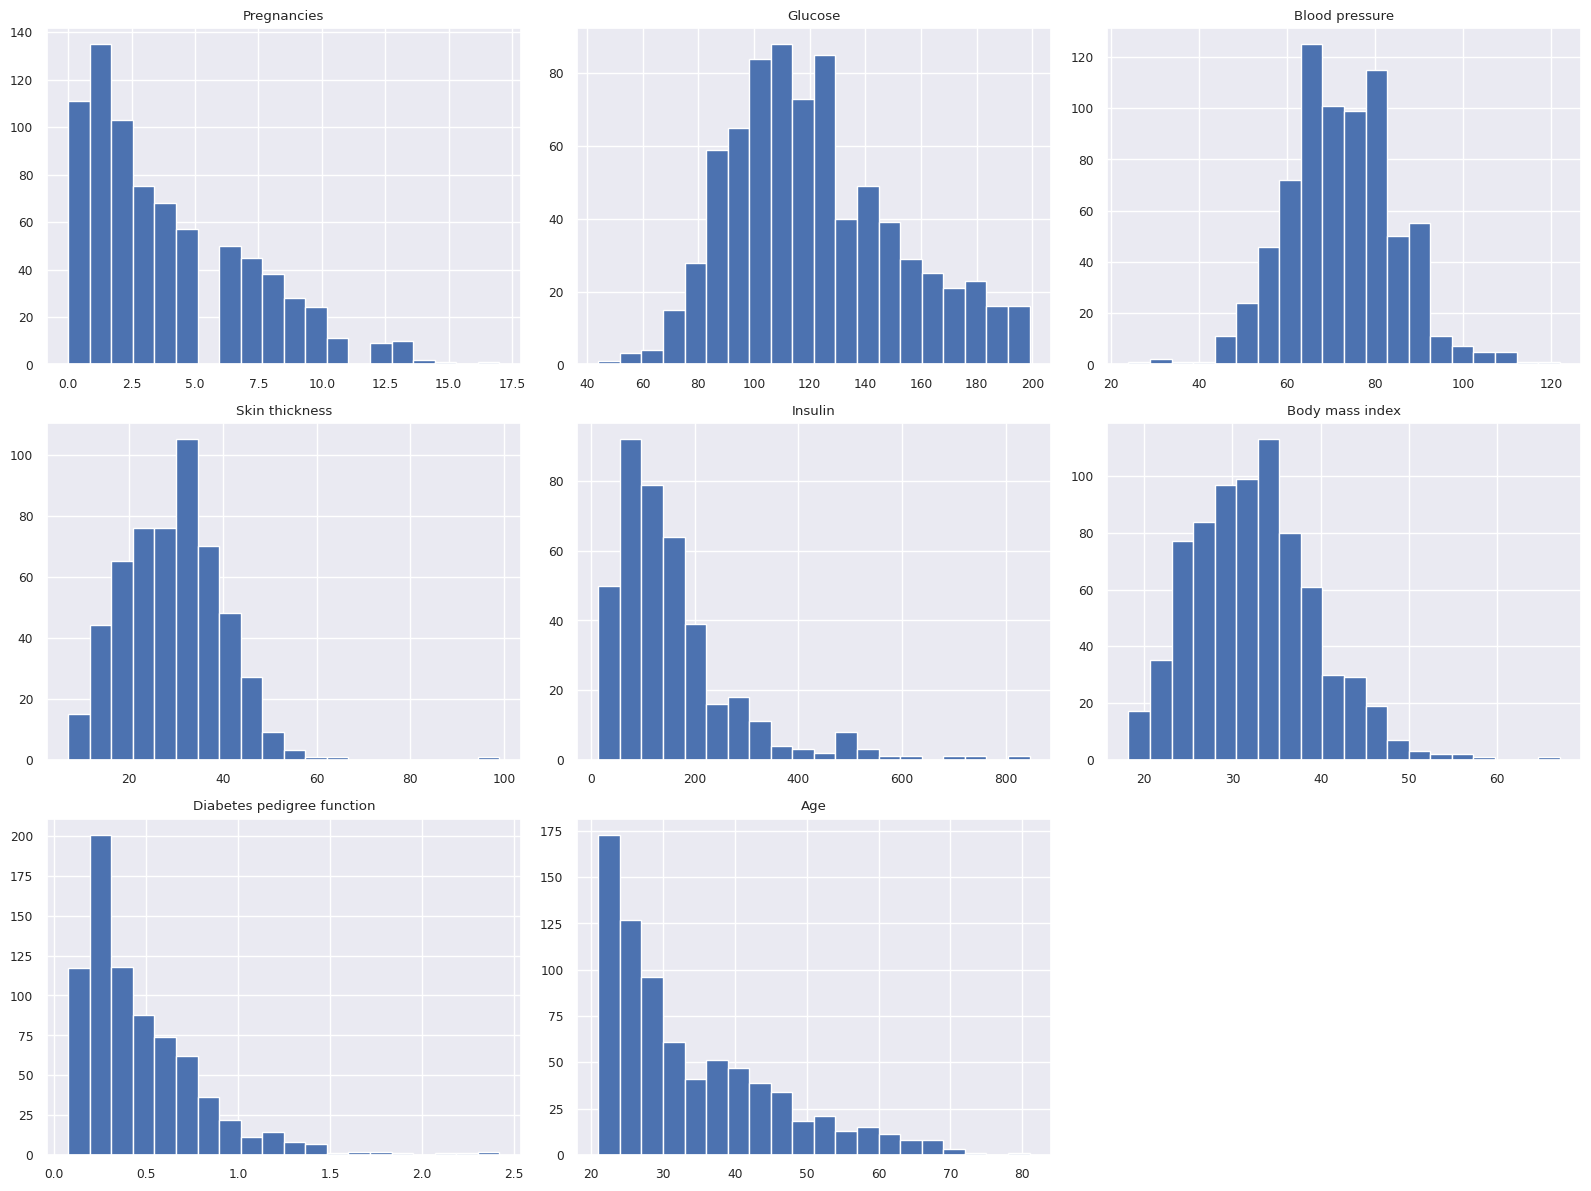

In [23]:
# @title **Generate histograms for all numerical variables**
df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

***Interpretation***

The histogram panels show the several variables are right-skewed, particularly Pregnancies, Insulin, Diabetes pedigree function, and Age.
- Pregnancies is strongly right-skewed; most people have relatively few pregnancies with fewer observations at higher counts.
- Glucose is roughly bell-shaped but somewhat right-skewed; most vales are around 80-140, with some higher values extending toward 200.
- Blood pressure is fairly centered around 60-90 with some lower and higher values.
- Skin thickness is mostly concentrated around 20-40, with a right tail and a few unusually high values.
- Insulin is strongly right-skewed with most observations at lower values and a long tail extending toward 800+. This is one of the most noticeable distributions.
- BMI is concentrated around 25-40 and moderately right-skewed.
- Diabetes pedigree function is strongly right-skewed with most values below 1 and a small number of higher values.
- Age is also right-skewed with most participants younger than about 50 and fewer older participants.

The histograms indicate that the predictors have different distributions and ranges, which is important to consider during prepocessing and modeling.

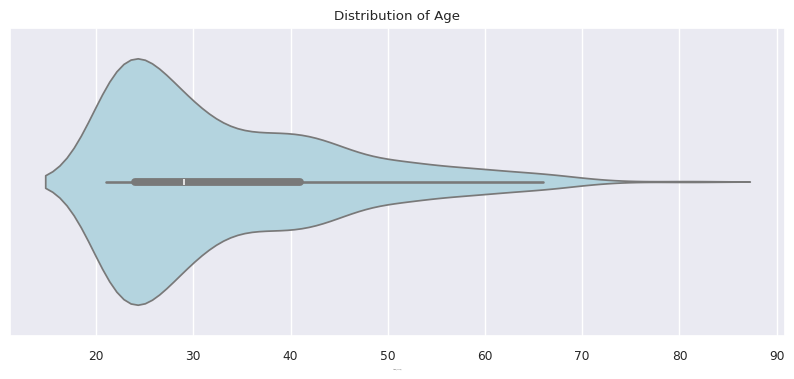

In [24]:
# @title **Example of a violin plot**
import seaborn as sns
import matplotlib.pyplot as plt

variable = "Age"

plt.figure(figsize=(10,4))

sns.violinplot(
    x=df[variable],
    color="lightblue",
    inner="box"
)

plt.title("Distribution of Age")
plt.xlabel("Age (years)")


plt.show()

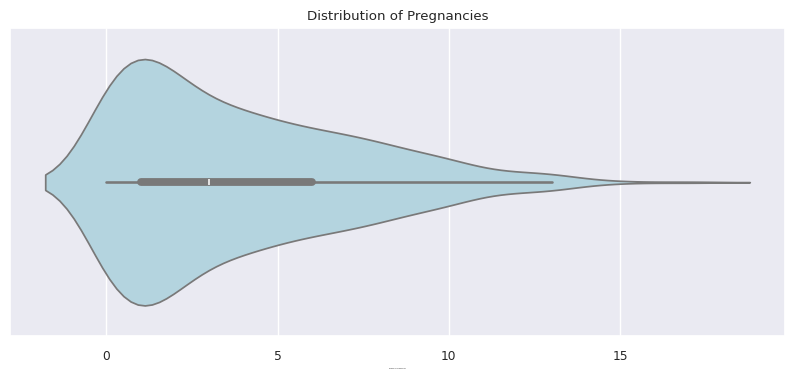

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

variable = "Pregnancies"

plt.figure(figsize=(10,4))

sns.violinplot(
    x=df[variable],
    color="lightblue",
    inner="box"
)

plt.title("Distribution of Pregnancies")
plt.xlabel("Number of Pregnancies")


plt.show()

***Interpretation***

**Age** - The violin plot shows that most participants are concentrated in the younger age ranges, particularly in their 20s and 30s. The distribution becomes narrower as age increases, showing that there are fewer older participants. Overall, Age has a right-skewed distribution, with most observations at younger ages and a smaller number of observations extending into older age groups.

**Pregnancies** - The violin plot shows that most participants have between 0 and 5 pregnancies, with the highest concentration around 1–3 pregnancies. The distribution is strongly right-skewed, with fewer observations at higher numbers of pregnancies and a long tail extending toward about 17 pregnancies.

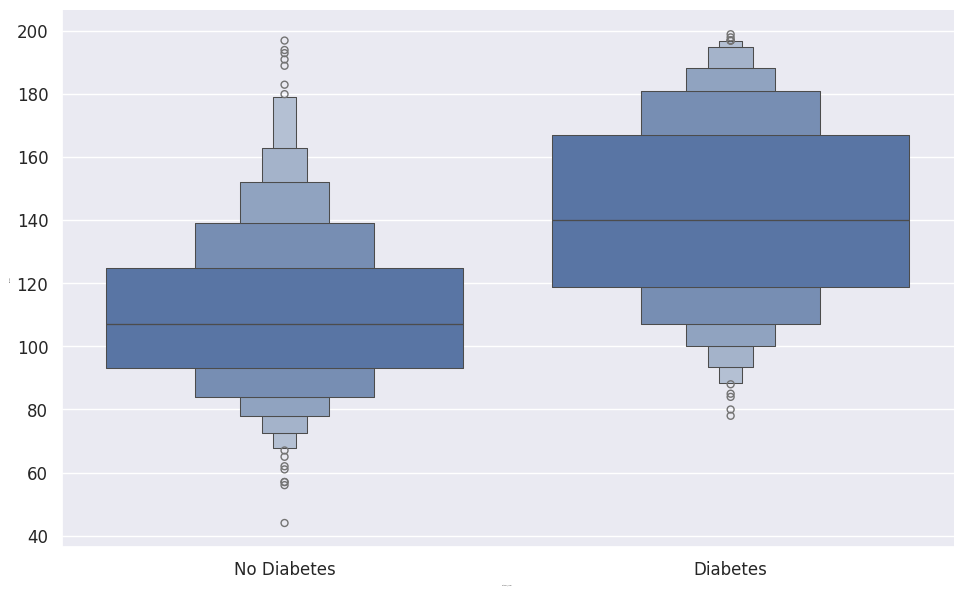

In [26]:
# @title **Example of categorical plot**
# Create readable labels for Outcome
df["Outcome_label"] = df["Outcome"].map({
    0: "No Diabetes",
    1: "Diabetes"
})

# Define the plot variables
x_var = "Outcome_label"
y_var = "Glucose"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the plot
g = sns.catplot(x=x_var, y=y_var, data=df, kind='boxen', height=6, aspect=1.6, estimator=np.mean);

# Dynamically set axis labels
g.set_axis_labels(x_var, y_var)
g.set_titles("{col_name}")

# Optionally set font size
g.set(xlabel=x_var, ylabel=y_var)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

***Interpretation***

The plot shows that glucose levels are generally higher among participants with diabetes compared with those without diabetes. The center of the Diabetes group is around 140, while the No Diabetes group is around 107. Although there is some overlap between the groups, the overall difference supports the earlier correlation results showing that Glucose has a strong relationship with the diabetes outcome.

In [27]:
# @title **Define a function to create a boxplot and histogram combo**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
def histogram_boxplot(feature, figsize=(10,6), bins=None):
    """ Boxplot and histogram combined (horizontal boxplot version)
    feature: 1-d feature array
    figsize: size of fig (default (10,6))
    bins: number of bins (default None / auto)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from scipy.stats import norm

    sns.set(font_scale=1)
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (.25, .75)},
        figsize=figsize
    )

    # Horizontal boxplot
    sns.boxplot(x=feature, ax=ax_box2, showmeans=True, color='red')

    # Histogram
    if bins:
        sns.histplot(feature, kde=False, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(feature, kde=False, ax=ax_hist2)

    # Add central tendency lines to histogram
    ax_hist2.axvline(np.mean(feature), color='black', linestyle='--', label='Mean')
    ax_hist2.axvline(np.median(feature), color='green', linestyle='-', label='Median')
    ax_hist2.axvline(feature.mode()[0], color='red', linestyle='dashed', linewidth=1, label='Mode')

    ax_hist2.legend()
    plt.tight_layout()
    plt.show()

print("Function successfully created")

Function successfully created


This function creats a histogram and boxplot together for a selected variable. The histogram shows the distribution of the data, while the boxplot helps identify the median, spread, and potential outliers. The plot also displays the mean, median, and mode on the histogram, making it easier to compare these measures of central tendency. Combining these visualizations provides a more complete view of the variable's distribution and can help identify patterns or unusual values during exploratory data analysis.

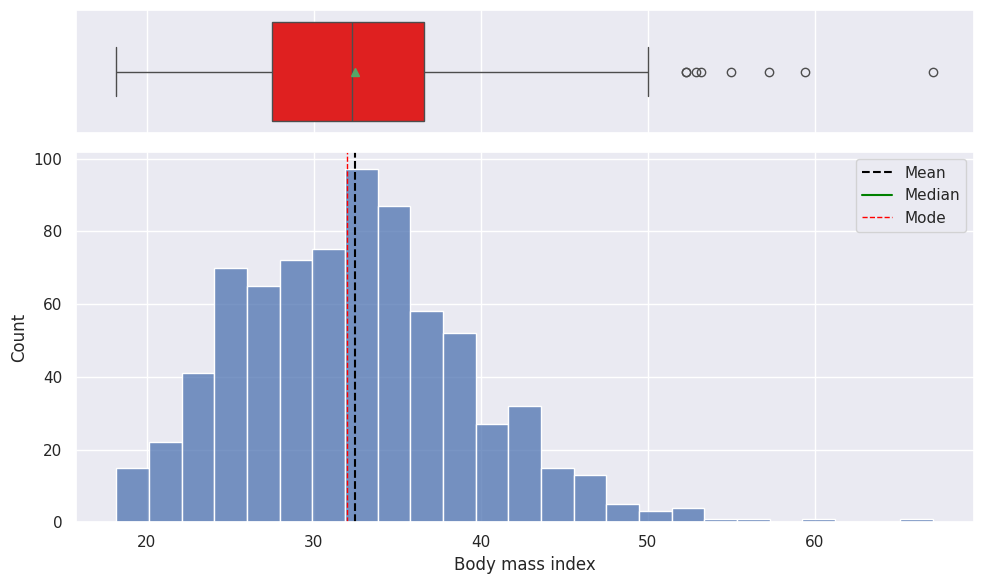

In [28]:
# @title **Example of a combination boxplot and histogram**

histogram_boxplot(df['Body mass index']) # CHANGE THE CONTINUOUS VARIABLE HERE

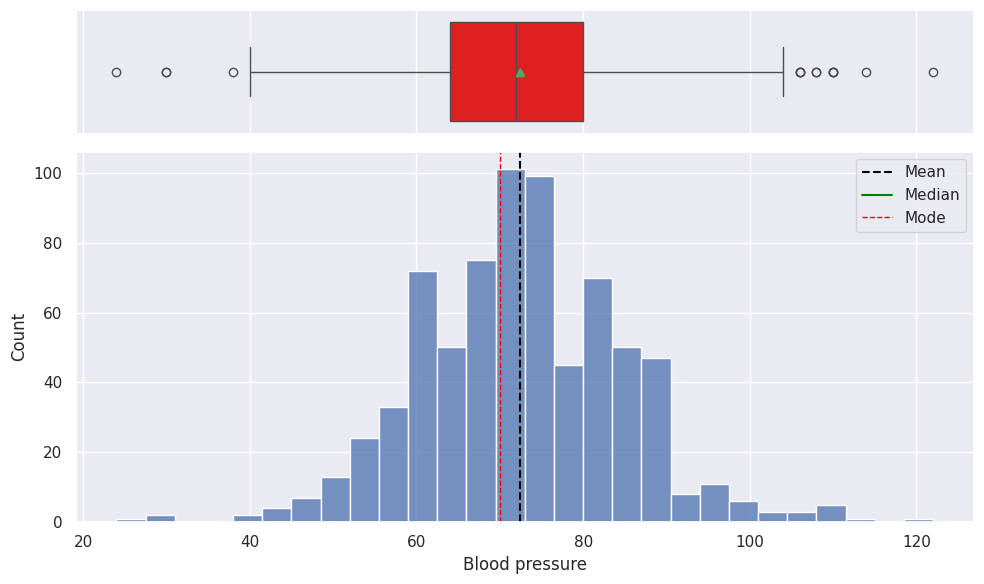

In [29]:
histogram_boxplot(df['Blood pressure'])

***Interpretation***

For BMI, most values are around 25-40. The mean is approximately 32.5, while the median is about 32.3, showing that the typical BMI is around the low 30s. Since the mean is slightly higher than the median, this is consistent with the slight right skew seen in the distribution.

For blood pressure, most values are around 60-90. The mean is approximately 72.4, while the median is 72, showing that the typical blood pressure is around 72. The mean and median are very close, suggesting that the center of the distribution is fairly similar between the two measures, although there are some lower and higher values.

Combining the histogram and boxplot is useful because it shows the overall distribution while also highlighting the mean, median, spread, and potential outliers in one figure.

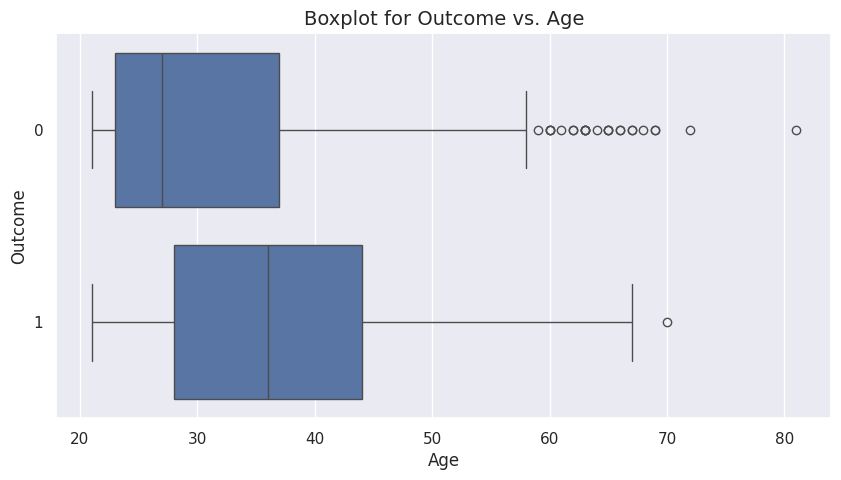

In [30]:
# @title **Example of boxplot with the primary outcome and a continuous variable**

# Define variables
x_var = "Age" # CHANGE VARIABLE HERE
y_var = "Outcome"  # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=x_var, y=y_var, data=df)

# Dynamic labels and title
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'Boxplot for {y_var} vs. {x_var}', fontsize=14)

plt.show()

***Interpretation***

The boxplot shows that participants with Outcome = 1 (Diabetes) tend to be older than those with Outcome = 0 (No Diabetes). The median age is approximately 36 for the Diabetes group compared with the median age of 27 for the No Diabetes group. There is some overlap between the groups, but the overall distribution suggests that age is associated with diabetes outcome. The plot also shows several older observations that may be considered potential outliers.

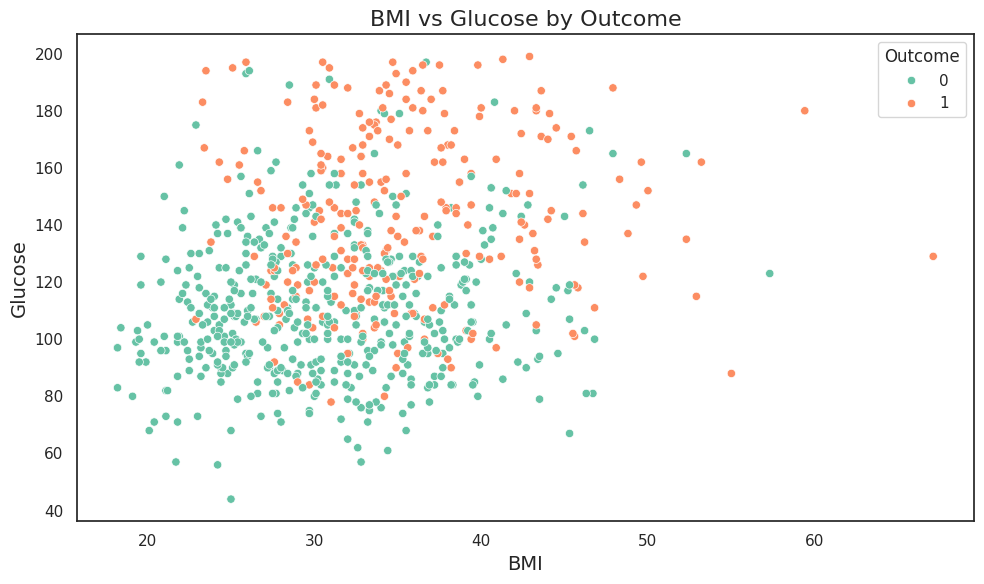

In [31]:
# @title **Example of a scatterplot**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the scatterplot
sns.set(style="white")  # Clean background without gridlines
plt.figure(figsize=(10, 6))

# Scatterplot
sns.scatterplot(x='Body mass index', y='Glucose', hue='Outcome', data=df, palette='Set2')

# Add title and axis labels
plt.title('BMI vs Glucose by Outcome', fontsize=16)
plt.xlabel('BMI', fontsize=14)
plt.ylabel('Glucose', fontsize=14)

# Remove gridlines
plt.grid(False)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Show the plot
plt.show()

***Interpretation***

The scatterplot shows a generally positive relationship between BMI and Glucose, although the observations are fairly spread out. Participants with Diabetes (Outcome = 1) appear more frequently at higher glucose levels, while the No Diabetes group is more concentrated at lower glucose levels. The Diabetes group is distributed across a wide range of BMI values, with many observations concentrated around 30-40. In comparison, the difference between the two outcome groups is more apparent for Glucose, where Diabetes cases are more concentrated at higher values. There is still considerable overlap between the two groups, suggesting that BMI and Glucose alone do not completely distinguish the two outcomes.

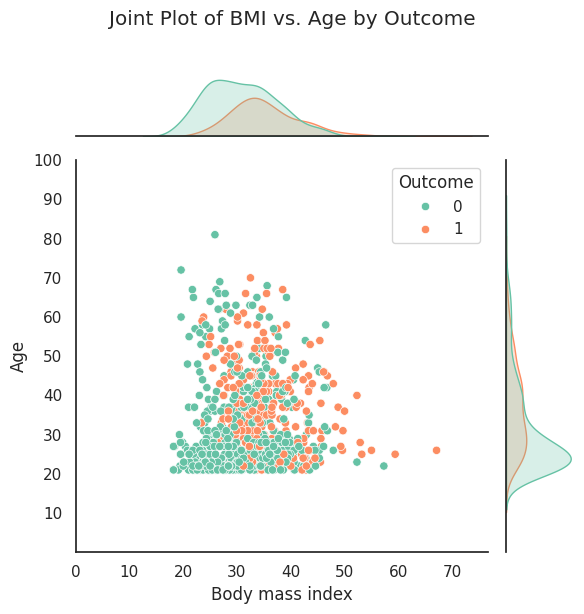

In [32]:
# @title **Example of a joint plot (3 variables)**
g = sns.jointplot(
    x='Body mass index', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE
    hue='Outcome',
    data=df,
    palette='Set2',
    height=6,
)

# Set x-axis and y-axis limits
g.ax_joint.set_xlim(left=0)
g.ax_joint.set_ylim(bottom=0)

# Set y-axis ticks to increase by 10
y_min, y_max = g.ax_joint.get_ylim()
g.ax_joint.set_yticks(np.arange(10, y_max + 10, 10))

# Add title
plt.suptitle("Joint Plot of BMI vs. Age by Outcome", y=1.02)
plt.tight_layout()
plt.show()

***Interpretation***

The joint plot shows the relationship between BMI and Age for the two diabetes outcome groups. Most observations are concentrated between ages 20-40 and BMI values of about 25-40. The Diabetes group appears somewhat more concentrated at older ages, while the BMI distributions overlap considerably between the two groups. The joint plot is useful because it allows us to examine BMI and Age together while also comparing the two outcome groups, helping show patterns and overlap that may not be as clear when looking at each variable separately.

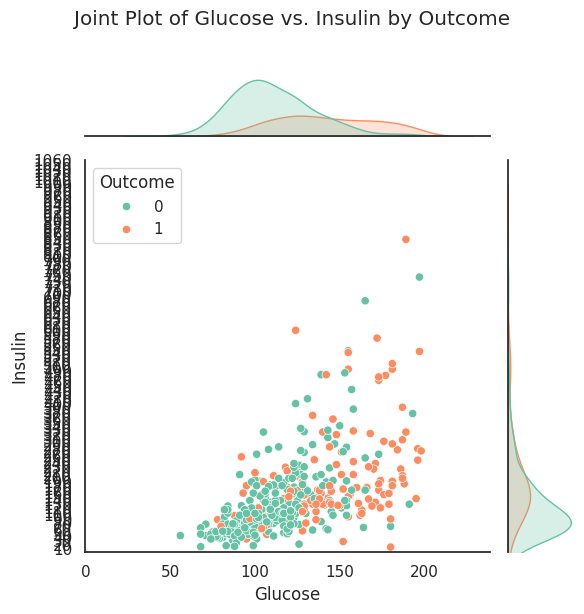

In [33]:
# @title **Example of a joint plot (3 variables)**
g2 = sns.jointplot(
    x='Glucose', # CHANGE VARIABLE HERE
    y='Insulin', # CHANGE VARIABLE HERE
    hue='Outcome',
    data=df,
    palette='Set2',
    height=6,
)

# Set x-axis and y-axis limits
g2.ax_joint.set_xlim(left=0)
g2.ax_joint.set_ylim(bottom=0)

# Set y-axis ticks to increase by 10
y_min, y_max = g2.ax_joint.get_ylim()
g2.ax_joint.set_yticks(np.arange(10, y_max + 10, 10))

# Add title
plt.suptitle("Joint Plot of Glucose vs. Insulin by Outcome", y=1.02)
plt.tight_layout()
plt.show()

***Interpretation***

The joint plot shows the relationship between Glucose and Insulin for the two diabetes outcome groups. Most observations are concentrated at lower insulin levels and glucose values around 80–140. The Diabetes group appears more frequently at higher glucose levels, while the two groups still show considerable overlap.

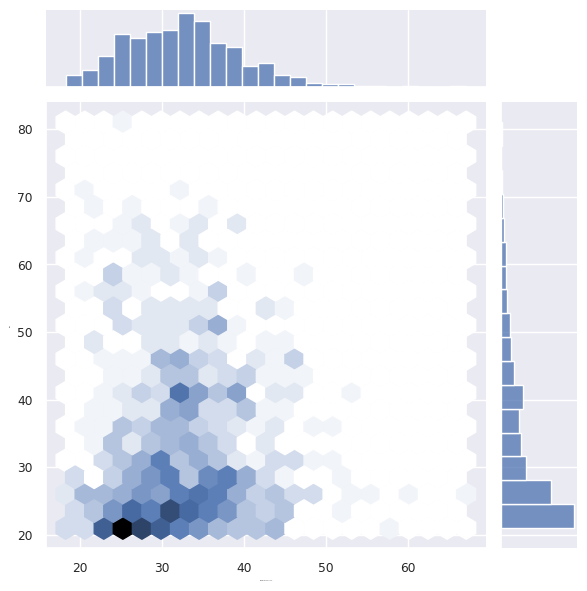

In [34]:
# @title **Example of a joint plot of a different kind (2 variables)**

sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

sns.jointplot(
    x='Body mass index', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='hex',
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

***Interpretation***

The hexbin plot shows the distribution of BMI and Age, with darker areas representing a higher concentration of observations. Most participants are concentrated around ages 20-30 and BMI values around 25-35. The plot also shows fewer observations at older ages and higher BMI values. This type of plot is useful for showing the density of observations when there are many data points that could overlap in a traditional scatterplot.

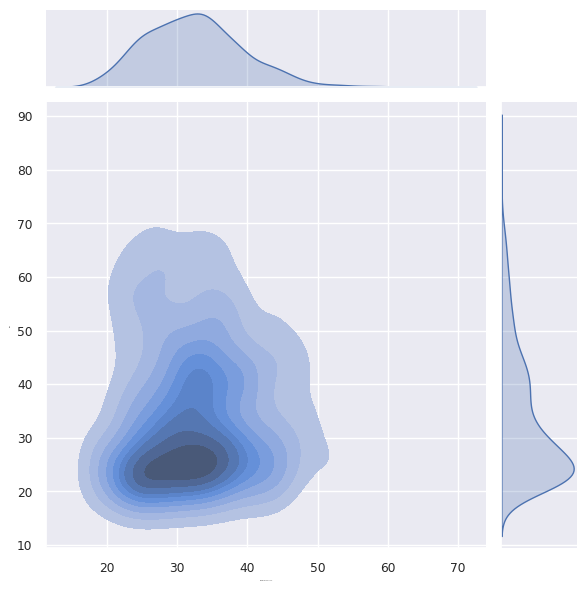

In [35]:
# @title **Another example of a joint plot of a different kind (2 variables)**
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

sns.jointplot(
    x='Body mass index', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='kde',
    fill = True,
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

***Interpretation***

The density plot shows that most observations are concentrated around ages 20-30 and BMI values around 25-35. The darker areas represent regions with more observations, while the lighter areas represent fewer observations. There appears to be some spread toward older ages and higher BMI values, but the plot does not show a strong or clearly defined relationship between the two variables. Similar to other joint plot, this type of plot helps show the concentration and distribution of observations without the overlap that can occur in a traditional scatterplot.

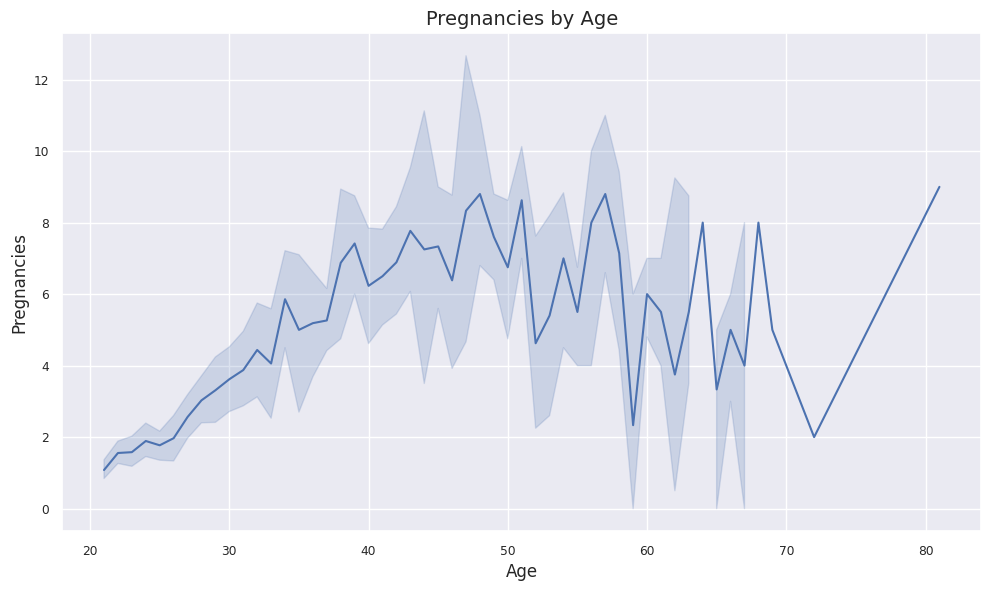

In [36]:
# @title **Example of a line plot**

# Define x and y columns
x_col = 'Age' # CHANGE VARIABLE HERE
y_col = 'Pregnancies' # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Set up figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create lineplot
sns.lineplot(x=x_col, y=y_col, data=df, ax=ax)

# Set axis labels and title explicitly
ax.set_xlabel(x_col, fontsize=12)
ax.set_ylabel(y_col, fontsize=12)
ax.set_title(f'{y_col} by {x_col}', fontsize=14)

# Ensure labels are not cut off
plt.tight_layout()

# Show the plot
plt.show()

***Interpretation***

This line plot examines how the number of pregnancies changes across age. The line represents the observed relationship between Age and Pregnancies, while the shaded area shows the variability around the estimated line. This visualization can help identify general trends and changes in the relationship between the two variables.

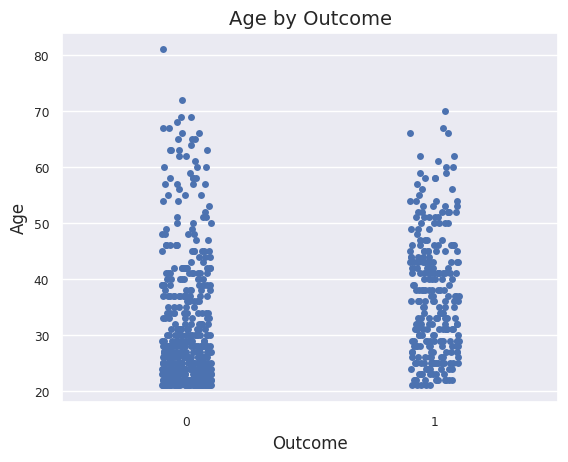

In [37]:
# @title **Example of a strip plot**

# Define axis variables
x_var = "Outcome"  # CHANGE VARIABLE HERE
y_var = "Age"      # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
sns.stripplot(data=df, x=x_var, y=y_var, jitter=True)
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

***Interpretation***

The plot shows the individual age observations for each diabetes outcome group. Both groups have many participants in their 20s and 30s, but the Diabetes group appears to have more observations at older ages. There is still considerable overlap between the groups, suggesting that Age may be associated with the outcome but does not entirely separate the two groups by itself. This plot shows the actual disribution and spread of individual observations within each outcome group.

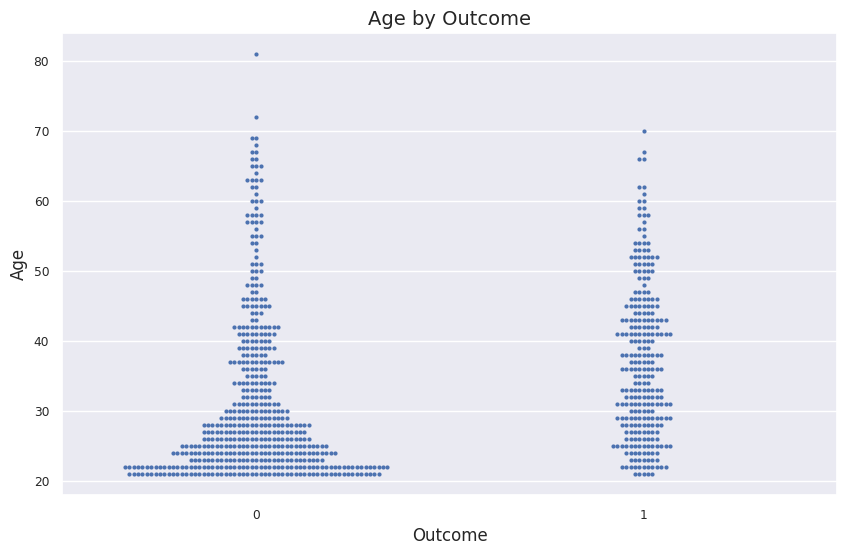

In [38]:
# @title **Example of a swarm plot**

x_var = "Outcome"
y_var = "Age"

plt.figure(figsize=(10, 6))
sns.swarmplot(data=df, x=x_var, y=y_var, size=3)

plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

***Interpretation***

Similar to the line plot, this swarm plot shows that both outcome groups have many observations in their 20s and 30s. The No Diabetes group is more concentrated among younger participants, while the Diabetes group is more spread toward older ages, particularly into the 40s-60s. There is still considerable overlap between the groups, but the plot suggests that diabetes is more common among older participants. This visualization shows clearer concentration and spread of individual observations within each outcome group.

**Link to other data visualizations: https://seaborn.pydata.org/examples/index.html**

## **Inferential Statistics**

In [39]:
# @title **Import additional inferential statistics libraries**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
import math
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind

print("Libraries successfully imported.")

Libraries successfully imported.


***Interpretation***

The imported libraries are for the statistical analysis. The one-sample t-test can be used to compare a sample mean to a specified value, while the independent t-test can be used to compare the means of two separate groups. These tests will be used to examine whether observed differences in means are statistically significant.

In [40]:
# @title **Example of a one-sample t-test**

from scipy.stats import ttest_1samp

variable = "Body mass index"       # CHANGE VARIABLE HERE
threshold = 30        # CHANGE REFERENCE VALUE HERE
alpha = 0.05          # CHANGE SIGNIFICANCE LEVEL HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing observations.
values = df[variable].dropna()

if len(values) < 2 or values.std() == 0:
    raise ValueError(
        "The test requires at least two nonmissing values and nonzero variance."
    )

# Perform a two-sided one-sample t-test.
t_statistic, p_value = ttest_1samp(values, popmean=threshold)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"is {direction} than {threshold}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence that the population mean "
        f"{variable} differs from {threshold}."
    )

print(f"Null hypothesis: The population mean {variable} equals {threshold}.")
print(f"Alternative hypothesis: The population mean {variable} differs from {threshold}.")
print(f"\nNonmissing observations: {len(values)}")
print(f"Sample mean: {values.mean():.3f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean Body mass index equals 30.
Alternative hypothesis: The population mean Body mass index differs from 30.

Nonmissing observations: 757
Sample mean: 32.457
t-statistic: 9.764
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean Body mass index is higher than 30.


***Intepretation***

A one-sample t-test was used to determine whether the mean BMI differs from 30. The sample mean was 32.457 based on 757 nonmissing observations. The test produced a t-statistic of 9.764 and a p-value < 0.001. Since the p-value is below 0.05, we reject the null hypothesis. There is evidence that the population mean BMI is higher than 30.

In [41]:
# @title **Independent samples t-test (specific to this dataset)**

from scipy.stats import ttest_ind

variable = "Body mass index"
group_col = "Outcome"
alpha = 0.05

label_map = {0: "Patients without diabetes", 1: "Patients with diabetes"}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing either the measurement or group.
test_data = df[[variable, group_col]].dropna()

if set(test_data[group_col].unique()) != {0, 1}:
    raise ValueError("The group variable must contain both groups, coded 0 and 1.")

# Set a consistent comparison order.
group1 = test_data.loc[test_data[group_col] == 0, variable]
group2 = test_data.loc[test_data[group_col] == 1, variable]

if len(group1) < 2 or len(group2) < 2:
    raise ValueError("Each group requires at least two nonmissing observations.")

if group1.var() == 0 and group2.var() == 0:
    raise ValueError("The test requires variation in at least one group.")

group1_name = label_map[0]
group2_name = label_map[1]

# Two-sided Welch's t-test.
t_statistic, p_value = ttest_ind(group1, group2, equal_var=False)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"for {group1_name.lower()} is {direction} than "
        f"for {group2_name.lower()}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference in population "
        f"mean {variable} between the two groups."
    )

print(f"Null hypothesis: The population mean {variable} is equal between groups.")
print(f"Alternative hypothesis: The population mean {variable} differs between groups.")

print(f"\n{group1_name}: n = {len(group1)}, mean = {group1.mean():.3f}")
print(f"{group2_name}: n = {len(group2)}, mean = {group2.mean():.3f}")
print(f"Mean difference (group 0 − group 1): {group1.mean() - group2.mean():.3f}")

print(f"\nWelch's independent samples t-test:")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean Body mass index is equal between groups.
Alternative hypothesis: The population mean Body mass index differs between groups.

Patients without diabetes: n = 491, mean = 30.860
Patients with diabetes: n = 266, mean = 35.407
Mean difference (group 0 − group 1): -4.547

Welch's independent samples t-test:
t-statistic: -9.055
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean Body mass index for patients without diabetes is lower than for patients with diabetes.


***Interpretation***

A Welch's independent samples t-test was used to compare mean BMI between patients with and without diabetes. The mean BMI was 30.860 for patients without diabetes and 35.407 for patients with diabetes, a difference of about 4.55 BMI points. The p-value was < 0.001, so we reject the null hypothesis. There is evidence that mean BMI differs between the two groups, with patients with diabetes having a higher average BMI.

In [42]:
# @title **One-way ANOVA (specific to this dataset)**

import statsmodels.api as sm
from statsmodels.formula.api import ols

variable = "Glucose"
group_col = "Outcome"
alpha = 0.05

label_map = {
    0: "Patients without diabetes",
    1: "Patients with diabetes"
}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing the measurement or group.
test_data = df[[variable, group_col]].dropna().copy()

# Use standard column names for the model formula.
test_data.columns = ["measurement", "group"]
test_data["group"] = test_data["group"].astype("category")
test_data["group"] = test_data["group"].cat.remove_unused_categories()

group_summary = (
    test_data.groupby("group", observed=True)["measurement"]
    .agg(["count", "mean", "std"])
)

if len(group_summary) < 2:
    raise ValueError("ANOVA requires at least two groups.")

if (group_summary["count"] < 2).any():
    raise ValueError("Each group requires at least two nonmissing observations.")

if (group_summary["std"] == 0).all():
    raise ValueError("The test requires variation within at least one group.")

# Fit the model and calculate the ANOVA table.
anova_model = ols("measurement ~ C(group)", data=test_data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

f_stat = anova_table.loc["C(group)", "F"]
p_value = anova_table.loc["C(group)", "PR(>F)"]

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    interpretation = (
        f"There is evidence that at least two groups differ "
        f"in population mean {variable}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference "
        f"in population mean {variable} across groups."
    )

# Apply readable group labels for display.
group_summary.index = [
    label_map.get(group, str(group))
    for group in group_summary.index
]

print(f"Null hypothesis: Population mean {variable} is equal across all groups.")
print(f"Alternative hypothesis: At least one population mean differs.")

print("\nGroup summaries:")
display(group_summary.round(3))

print("\nANOVA table:")
display(anova_table.round(3))

print(f"\nF-statistic: {f_stat:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: Population mean Glucose is equal across all groups.
Alternative hypothesis: At least one population mean differs.

Group summaries:


,count,mean,std
Patients without diabetes,497,110.644,24.777
Patients with diabetes,266,142.320,29.599



ANOVA table:


,sum_sq,df,F,PR(>F)
C(group),173846.334,1.0,246.518,0.0
Residual,536661.802,761.0,NaN,NaN



F-statistic: 246.518
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that at least two groups differ in population mean Glucose.


***Interpretation***

A one-way ANOVA was used to compare mean Glucose between patients with and without diabetes. The mean glucose level was 110.644 for patients without diabetes and 142.320 for patients with diabetes. The ANOVA table reports an F-statistic of 246.518 and a p-value < 0.001. Since the p-value is below 0.05, we reject the null hypothesis and conclude that there is evidence that mean Glucose differs between the two groups, with patients with diabetes having a higher average glucose level.

The ANOVA table provides the calculations and results of the ANOVA test, including the F-statistic and p-value. Although ANOVA is often used to compare three or more groups, it can also be used with two groups. With only two groups in this dataset, the ANOVA is closely related to an independent samples t-test.

In [43]:
# @title **Chi-square test of independence (specific to this dataset)**

import pandas as pd
from scipy.stats import chi2_contingency

group_col = "Outcome"
variable = "Pregnancies"
threshold = 10
alpha = 0.05

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing values before creating categories.
test_data = df[[group_col, variable]].dropna().copy()
test_data["Above threshold"] = test_data[variable] > threshold

crosstab = pd.crosstab(
    test_data[group_col],
    test_data["Above threshold"]
)

if crosstab.shape[0] < 2 or crosstab.shape[1] < 2:
    raise ValueError("The test requires at least two observed categories per variable.")

# Run Pearson's chi-square test without continuity correction.
chi2_stat, p_value, dof, expected = chi2_contingency(
    crosstab, correction=False
)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

print("Observed counts (False = ≤ threshold; True = > threshold):")
display(crosstab)

print("\nExpected counts under independence:")
display(pd.DataFrame(
    expected,
    index=crosstab.index,
    columns=crosstab.columns
).round(3))

print(f"\nNull hypothesis: {group_col} and {variable} > {threshold} are independent.")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p {formatted_p}")

if (expected < 5).any():
    print(
        "\nSmall expected counts detected. For this 2×2 table, "
        "consider Fisher's exact test before interpreting the chi-square result."
    )

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print(
        f"Interpretation: There is evidence of an association between "
        f"{group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )
else:
    print("Decision: Fail to reject the null hypothesis.")
    print(
        f"Interpretation: There is insufficient evidence of an association "
        f"between {group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )

Observed counts (False = ≤ threshold; True = > threshold):


Above threshold,False,True
Outcome,,
0,486,14
1,248,20



Expected counts under independence:


Above threshold,False,True
Outcome,,
0,477.865,22.135
1,256.135,11.865



Null hypothesis: Outcome and Pregnancies > 10 are independent.
Chi-square statistic: 8.965
Degrees of freedom: 1
p = 0.003
Decision: Reject the null hypothesis.
Interpretation: There is evidence of an association between Outcome and having Pregnancies > 10, provided the test assumptions are met.


***Interpretation***

A chi-square test of independence was used to examine whether diabetes outcome was associated with having more than 10 pregnancies. The test produced a chi-square statistic of 8.965 with 1 degree of freedom and a p-value of 0.003. Since the p-value is below 0.05, we reject the null hypothesis. There is evidence of an association between diabetes outcome and having more than 10 pregnancies in this dataset. However, this test only shows an association and does not indicate that having more than 10 pregnancies causes diabetes.

In [44]:
# @title **Encode outcome labels as 0 and 1 (if needed)**

target_variable = "Outcome"
label_map = {"No Diabetes": 0, "Diabetes": 1}

outcome = df[target_variable]
observed_values = set(outcome.dropna().unique())

if observed_values.issubset({0, 1}):
    print("Outcome is already coded as 0/1.")

elif observed_values.issubset(set(label_map)):
    df[target_variable] = outcome.map(label_map)
    print("Outcome labels converted to 0/1.")

else:
    raise ValueError(
        f"Unexpected outcome values: {observed_values}. "
        "Update label_map to match your dataset."
    )

display(df[target_variable].head(10))

Outcome is already coded as 0/1.


,Outcome
0,1
1,0
2,1
3,0
4,1
5,0
6,1
7,0
8,1
9,1


***Interpretation***

The Outcome variable is already coded as 0 and 1, so no conversion was needed. In this dataset, 0 represents No Diabetes and 1 represents Diabetes. Keeping the outcome in this binary format allows it to be used directly as the target variable for the classification models later in the pipeline.

## **Supervised Machine Learning (Binary Classification)**

**Two examples:**
- Logistic Regression  
- Decision Tree  

**LOGISTIC REGRESSION:** Additional Info on Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

## **Logistic Regression**

In [45]:
if "Outcome_label" in df.columns:
    df = df.drop(columns=["Outcome_label"])

print("Outcome_label removed.")

# @title **Configure and split data for the automated ML pipeline**

from sklearn.model_selection import train_test_split

target_variable = "Outcome"  # CHANGE FOR YOUR DATASET

# Exclude rows with missing outcomes; do not impute the outcome.
ml_data = df.dropna(subset=[target_variable]).copy()

X = ml_data.drop(columns=[target_variable])
y = ml_data[target_variable]

# This demonstration expects numeric predictors and an outcome coded 0/1.
if set(y.unique()) != {0, 1}:
    raise ValueError("The outcome must contain both classes, coded 0 and 1.")

if not all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns):
    raise ValueError("This pipeline requires numeric predictors.")

y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

Outcome_label removed.
Training observations: 537
Test observations: 231


***Interpretation***

Before splitting the data, I had to remove the Outcome_label column. This column was created earlier for the visualization comparing glucose levels between the No Diabetes and Diabetes groups. It contained text labels such as "No Diabetes" and "Diabetes" rather than numeric values. Since the ML pipeline requires all predictors to be numeric, Outcome_label caused an error when the pipeline checked the predictor data types. I removed the column because it was only needed for visualization and was not an actual predictor.

After removing the column, the data was successfully divided into a training set of 537 observations and a test set of 231 observations, using approximately a 70/30 split. The stratify=y option was also used to maintain a similar proportion of the two outcome classes in both sets. The test set will be kept separate from model training so it can be used to evaluate model performance on unseen data.

In [46]:
# @title **Define a function to display a confusion matrix**

from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_actual, y_predict):
    """Display counts and percentages of all evaluated observations."""

    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])

    if cm.sum() == 0:
        raise ValueError("No observations with labels 0 or 1 to display.")

    cell_names = np.array([
        ["True negative", "False positive"],
        ["False negative", "True positive"]
    ])

    annotations = np.array([
        f"{name}\n{count}\n{count / cm.sum():.2%}"
        for name, count in zip(cell_names.flatten(), cm.flatten())
    ]).reshape(2, 2)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=annotations,
        fmt="",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

print("Function successfully created.")

Function successfully created.


***Interpretation***

This step creates a function to display a confusion matrix for the classification models. The confusion matrix compares the model's predicted outcomes with the actual outcomes and shows the number and percentage of true negatives, false positives, false negatives, and true positives. This will help evaluate not only how accurate the model is, but also what types of errors it makes when predicting diabetes.

In [47]:
# @title **Build logistic regression with automated preprocessing**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Learn imputation and scaling from training data only.
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="liblinear",
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

# Apply the fitted preprocessing and model to test data.
y_predict = logistic_pipeline.predict(X_test)
model_score = logistic_pipeline.score(X_test, y_test)

print(f"Test-set accuracy: {model_score:.2%}")
print(
    f"The model correctly classified {model_score:.2%} "
    "of observations in the test set."
)

Test-set accuracy: 74.46%
The model correctly classified 74.46% of observations in the test set.


***Interpretation***

A logistic regression model was trained to predict the diabetes outcome. The pipeline first used median imputation to handle missing predictor values and standardization to put the predictors on similar scales. These preprocessing steps were learned from the training data only to avoid data leakage.

The model achieved a test-set accuracy of 74.46%, meaning it correctly classified about 74% of the observations in the test set. This provides an overall measure of model performance, but accuracy alone does not show what types of predictions the model got wrong. The confusion matrix will provide more detail about the model's true positives, true negatives, false positives, and false negatives.

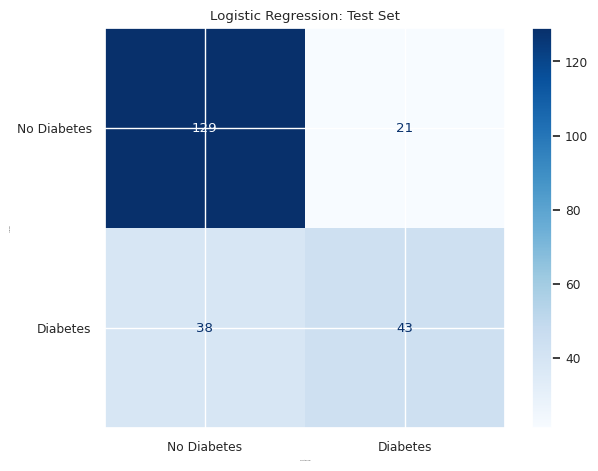

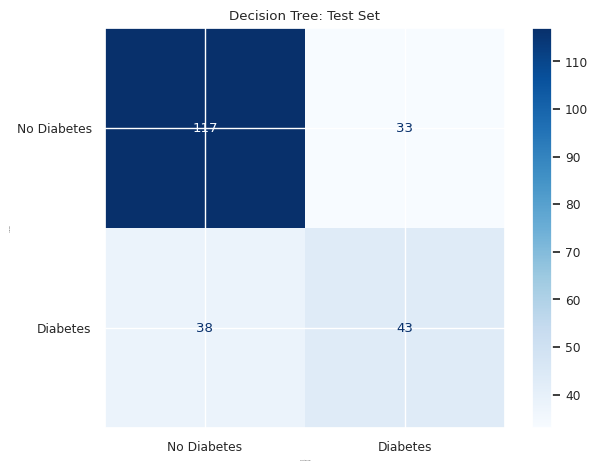

Test-set performance:


,Accuracy,Recall,Precision,F1,ROC AUC
Model,,,,,
Logistic Regression,0.745,0.531,0.672,0.593,0.836
Decision Tree,0.693,0.531,0.566,0.548,0.655


In [48]:
# @title **Automatically preprocess, train, and evaluate ML models**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Define the models to run automatically.
models = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

trained_pipelines = {}
results = []

for model_name, classifier in models.items():

    # Preprocessing is fitted using training data only.
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    # Apply scaling when appropriate for the model.
    if isinstance(classifier, LogisticRegression):
        steps.append(("scaler", StandardScaler()))

    steps.append(("classifier", classifier))

    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    positive_index = list(pipeline.classes_).index(1)
    probabilities = pipeline.predict_proba(X_test)[:, positive_index]

    trained_pipelines[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    })

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=[0, 1],
        display_labels=["No Diabetes", "Diabetes"],
        cmap="Blues"
    )
    plt.title(f"{model_name}: Test Set")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).set_index("Model")

print("Test-set performance:")
display(results_df.round(3))

***Interpretation***

The automated pipeline trained and evaluated two classification models: Logistic Regression and a Decision Tree. Both models used the same training and test sets, allowing their performance to be compared fairly. Missing predictor values were handled using median imputation based on the training data. Standardization was applied to the Logistic Regression model because it can benefit from predictors being on similar scales. The Decision Tree did not require scaling.

The results show that Logistic Regression performed better overall than the Decision Tree. Logistic Regression achieved an accuracy of 74.5%, meaning it correctly classified about three-quarters of the observations in the test set. The Decision Tree had an accuracy of 69.3%. This means that Logistic Regression made fewer overall classification errors on the test data.

The two models had the same recall of 53.1%. Recall measures how well the model identifies people who actually have diabetes. A recall of 53.1% means that both models correctly identified about 53% of the actual diabetes cases, while the remaining diabetes cases were classified as No Diabetes. This is important because a false negative represents someone who has diabetes but was not identified by the model.

Logistic Regression had a higher precision of 67.2%, compared with 56.6% for the Decision Tree. Precision measures how often a prediction of Diabetes was actually correct. Therefore, when Logistic Regression predicted that someone had diabetes, it was correct more often than the Decision Tree. The higher precision also means that the Logistic Regression model produced fewer false positive predictions relative to the number of positive predictions.

The F1 score was also higher for Logistic Regression (0.593) than for the Decision Tree (0.548). The F1 score combines precision and recall into a single measure, so the higher value suggests that Logistic Regression provided a better balance between correctly identifying diabetes cases and avoiding incorrect positive predictions.

The largest difference between the models was their ROC AUC. Logistic Regression had a ROC AUC of 0.836, while the Decision Tree had a ROC AUC of 0.655. ROC AUC measures how well a model can distinguish between the two outcome classes across different classification thresholds. The higher value for Logistic Regression suggests that it was substantially better at distinguishing between No Diabetes and Diabetes than the Decision Tree.

The Decision Tree confusion matrix provides more detail about its classification errors. It correctly identified 117 people without diabetes and 43 people with diabetes. These are the true negatives and true positives, respectively. It also incorrectly classified 33 people without diabetes as having diabetes, which are false positives. More importantly, it incorrectly classified 38 people with diabetes as not having diabetes, which are false negatives. These false negatives are particularly important in a health-related prediction problem because failing to identify someone who has diabetes could be more concerning than incorrectly flagging someone who does not have diabetes.

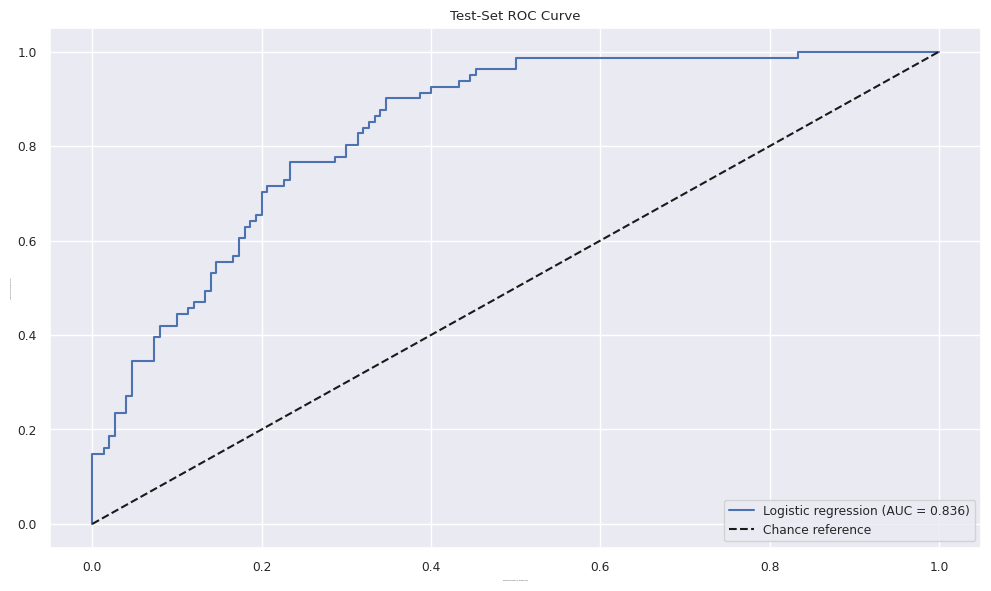

Test-set ROC AUC: 0.836


In [49]:
# @title **ROC curve and AUC for logistic regression**

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities for the positive class (1).
positive_index = list(logistic_pipeline.classes_).index(1)
y_probability = logistic_pipeline.predict_proba(X_test)[:, positive_index]

# Calculate test-set ROC AUC and curve.
logit_roc_auc = roc_auc_score(y_test, y_probability)
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {logit_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance reference")
plt.xlabel("False Positive Rate (1 − Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Test-Set ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Test-set ROC AUC: {logit_roc_auc:.3f}")

***Interpretation***

The ROC curve was used to evaluate how well the Logistic Regression model distinguishes between participants with and without diabetes across different classification thresholds. The y-axis represents the **true positive rate (sensitivity)**, while the x-axis represents the **false positive rate (1 - specificity)**. The dashed diagonal line represents chance performance, so a model that performs better should have a curve that remains above this line.

The Logistic Regression model had a ROC AUC of 0.836, which indicates good ability to distinguish between the two outcome groups. The curve is consistently above the chance reference line, showing that the model performs better than random classification. This result is also consistent with the model comparison results, where Logistic Regression had a much higher ROC AUC than the Decision Tree (**0.836 vs. 0.655**).

The ROC AUC should not be interpreted as the percentage of observations that were correctly classified. Instead, it measures the model's ability to distinguish between people with and without diabetes across different probability thresholds. Therefore, the ROC curve provides additional information about model performance beyond the accuracy, precision, and recall reported earlier.


In [50]:
# @title **Select a cutoff using training-set cross-validation**

import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Use the logistic_pipeline defined in the training block.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

# Each observation is predicted by a pipeline trained on other folds.
# Imputation and scaling are learned separately within each fold.
cv_probabilities = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)

positive_index = list(logistic_pipeline.classes_).index(1)

fpr, tpr, thresholds = roc_curve(
    y_train,
    cv_probabilities[:, positive_index]
)

# Exclude the infinite threshold representing no positive predictions.
finite = np.isfinite(thresholds)
j_scores = tpr[finite] - fpr[finite]
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[finite][optimal_idx]

print(f"Selected threshold: {optimal_threshold:.3f}")
print("Criterion: maximum cross-validation sensitivity + specificity − 1.")
print("Apply this cutoff to the fitted pipeline's test-set probabilities.")

Selected threshold: 0.443
Criterion: maximum cross-validation sensitivity + specificity − 1.
Apply this cutoff to the fitted pipeline's test-set probabilities.


***Interpretation***

This step selects a probability cutoff for the Logistic Regression model using 5-fold cross-validation on the training data. Logistic Regression produces a probability of diabetes for each observation, and a cutoff is used to convert those probabilities into a final prediction of No Diabetes or Diabetes.

The default cutoff is often 0.50, but the pipeline selected a lower cutoff of 0.443. This means observations with a predicted probability of 0.443 or higher will be classified as Diabetes. The cutoff was selected using Youden's J statistic, which looks for the threshold that provides a balance between sensitivity and specificity.

Using cross-validation on the training data is important because it allows the cutoff to be selected without using the test set. The test set can therefore remain separate and be used later to provide a more unbiased evaluation of the model's performance. Lowering the cutoff may help the model identify more people with diabetes, but it may also result in more false-positive predictions. The effect of this new cutoff will be evaluated in the next step.

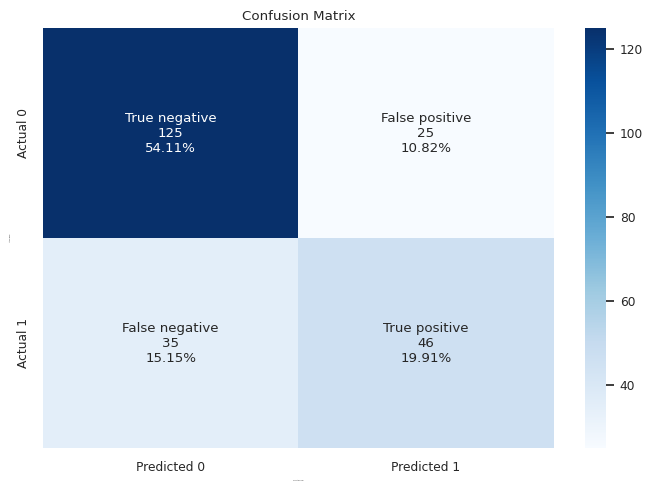

In [51]:
# @title **Make confusion matrix using the selected cutoff**

positive_index = list(logistic_pipeline.classes_).index(1)

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

make_confusion_matrix(y_test, y_pred_ts)

***Interpretation***

The selected probability cutoff of 0.443 was applied to the Logistic Regression model's test-set probabilities to create the final predictions. The confusion matrix shows 125 true negatives, 25 false positives, 35 false negatives, and 46 true positives out of 231 test observations.

The model correctly identified 125 participants who did not have diabetes and 46 participants who did have diabetes. It incorrectly classified 25 participants without diabetes as having diabetes and missed 35 participants who actually had diabetes. Compared with the earlier Decision Tree confusion matrix, the Logistic Regression model using the selected cutoff had fewer false positives (25 vs. 33) and fewer false negatives (35 vs. 38), while also correctly identifying more true negatives and true positives.

The cutoff of 0.443 was selected using cross-validation on the training data rather than the test set. This is important because it keeps the test data separate from the cutoff-selection process. The next step should compare the performance metrics at this cutoff to the original Logistic Regression results to determine how changing the cutoff affected model performance.

In [52]:
# @title **Compare training and test F1 at the selected cutoff**

from sklearn.metrics import f1_score

positive_index = list(logistic_pipeline.classes_).index(1)

train_probabilities = logistic_pipeline.predict_proba(
    X_train
)[:, positive_index]

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_tr = (train_probabilities >= optimal_threshold).astype(int)
y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

print(f"Selected cutoff: {optimal_threshold:.3f}")
print(f"Training F1: {f1_score(y_train, y_pred_tr, zero_division=0):.3f}")
print(f"Test F1: {f1_score(y_test, y_pred_ts, zero_division=0):.3f}")

Selected cutoff: 0.443
Training F1: 0.669
Test F1: 0.605


***Interpretation***

Using the selected cutoff of 0.443, the Logistic Regression model had a training F1 score of 0.669 and a test F1 score of 0.605. The lower test F1 is expected because the test data contains observations that were not used to train the model. The difference between the training and test F1 scores is 0.064, which shows some decrease in performance but not a very large gap.

Comparing training and test performance is useful for identifying potential overfitting. A large difference between the two scores could indicate that the model performs well on the training data but does not generalize well to new observations. In this case, the relatively modest difference suggests that the model maintains a similar level of performance on the unseen test data. However, F1 score alone is not enough to determine whether the model generalizes well, so it should be considered along with the other evaluation metrics.

## **Decision Tree**

**DECISION TREE: https://scikit-learn.org/stable/modules/tree.html#**

In [53]:
# @title **Import libraries for decision tree training and evaluation**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Decision tree libraries imported successfully.")

Decision tree libraries imported successfully.


***Interpretation***

This step imports the libraries needed to build, tune, visualize, and evaluate the Decision Tree model. The pipeline will use median imputation to handle missing predictor values, while GridSearchCV and stratified cross-validation can be used to find better model settings. Several classification metrics are also imported so the Decision Tree can be evaluated using more than just accuracy. The successful output confirms that the required libraries were imported without errors.

In [54]:
# @title **Build and tune decision tree using cross-validation F1**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Choose the metric used for tuning.
scoring_metric = "f1"  # Alternatives: "recall", "precision", "accuracy"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

dtree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Pipeline parameters require the step name prefix.
parameters = {
    "classifier__max_depth": [2, 4, 6, 8],
    "classifier__min_samples_leaf": [5, 10, 15],
    "classifier__max_leaf_nodes": [5, 10, 15],
    "classifier__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

grid_obj = GridSearchCV(
    estimator=dtree_pipeline,
    param_grid=parameters,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_obj.fit(X_train, y_train)

# Already refitted on the full training set; no additional fit is needed.
dtree = grid_obj.best_estimator_

print("Decision tree pipeline built and tuned.")
print(f"Best mean cross-validation {scoring_metric}: {grid_obj.best_score_:.3f}")
print("Selected parameters:")
print(grid_obj.best_params_)

Decision tree pipeline built and tuned.
Best mean cross-validation f1: 0.682
Selected parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__max_leaf_nodes': 10, 'classifier__min_samples_leaf': 5}


***Interpretation***

The Decision Tree was tuned using 5-fold stratified cross-validation, with F1 score selected as the metric for choosing the best model. F1 was used because it balances precision and recall, which is useful for this classification problem because both correctly identifying diabetes cases and limiting incorrect positive predictions are important.

The grid search tested different combinations of tree complexity and class-weight settings. These included maximum tree depth, minimum observations required in each leaf, maximum number of leaf nodes, and whether to use balanced class weights. The best combination had a maximum depth of 8, a maximum of 10 leaf nodes, at least 5 observations per leaf, and balanced class weights.

The best mean cross-validation F1 score was 0.682. The selection of class_weight="balanced" suggests that giving additional weight to the less frequent Diabetes class improved the model's performance during cross-validation. However, this score was calculated using the training data through cross-validation and should not be directly compared with the previous test-set F1 of 0.548. The tuned Decision Tree needs to be evaluated on the unseen test set before determining whether tuning improved its performance.

In [55]:
# @title **Function to calculate accuracy, recall, precision, and F1**

from sklearn import metrics

def get_metrics_score(model, flag=True):
    """Evaluate a fitted classifier on the existing training and test sets."""

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_acc = metrics.accuracy_score(y_train, pred_train)
    test_acc = metrics.accuracy_score(y_test, pred_test)

    train_recall = metrics.recall_score(
        y_train, pred_train, zero_division=0
    )
    test_recall = metrics.recall_score(
        y_test, pred_test, zero_division=0
    )

    train_precision = metrics.precision_score(
        y_train, pred_train, zero_division=0
    )
    test_precision = metrics.precision_score(
        y_test, pred_test, zero_division=0
    )

    train_f1 = metrics.f1_score(y_train, pred_train, zero_division=0)
    test_f1 = metrics.f1_score(y_test, pred_test, zero_division=0)

    score_list = [
        train_acc, test_acc,
        train_recall, test_recall,
        train_precision, test_precision,
        train_f1, test_f1
    ]

    if flag:
        print(f"{'Metric':<12} {'Training':>10} {'Test':>10}")
        for name, train_value, test_value in [
            ("Accuracy", train_acc, test_acc),
            ("Recall", train_recall, test_recall),
            ("Precision", train_precision, test_precision),
            ("F1", train_f1, test_f1)
        ]:
            print(f"{name:<12} {train_value:>10.3f} {test_value:>10.3f}")

    return score_list

print("Metric evaluation function successfully defined.")

Metric evaluation function successfully defined.


***Interpretation***

This step creates a reusable function to evaluate a fitted classification model using accuracy, recall, precision, and F1 score. The function calculates each metric for both the training and test sets so that model performance can be compared between data used for training and unseen data.

Comparing training and test performance is useful for identifying potential overfitting. If a model performs substantially better on the training data than the test data, it may not generalize well to new observations. Creating this function also makes the pipeline more efficient because the same evaluation process can be applied to different models without repeating the code.

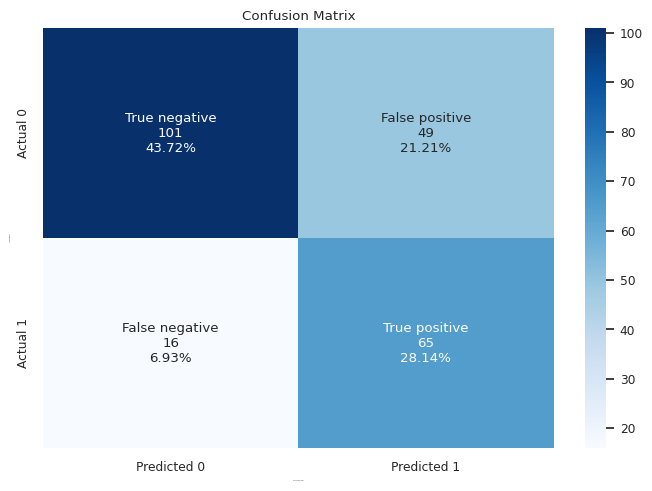

In [56]:
# @title **Display confusion matrix for the tuned decision tree**

y_pred_tree = dtree.predict(X_test)

make_confusion_matrix(y_test, y_pred_tree)

***Interpretation***


The confusion matrix shows the performance of the tuned Decision Tree on the test set. The model correctly classified **101 participants without diabetes** and **65 participants with diabetes**, resulting in 101 true negatives and 65 true positives. It also produced **49 false positives**, where participants without diabetes were predicted to have diabetes, and **16 false negatives**, where participants with diabetes were predicted to not have diabetes.

One of the main differences from the original Decision Tree is the reduction in false negatives. The tuned model missed **16 diabetes cases**, compared with **38** for the original Decision Tree. This corresponds to a recall of approximately **80.2%**, meaning the tuned model correctly identified about 80% of the participants who actually had diabetes. However, this improvement came with more false positives, with 49 participants without diabetes incorrectly classified as having diabetes.

The reduction in false negatives is important for this health-related classification problem because missing an individual who has diabetes may be more concerning than incorrectly identifying someone without diabetes as having diabetes. The next step will be to examine the full set of evaluation metrics to determine whether the improvement in recall also resulted in better overall model performance.


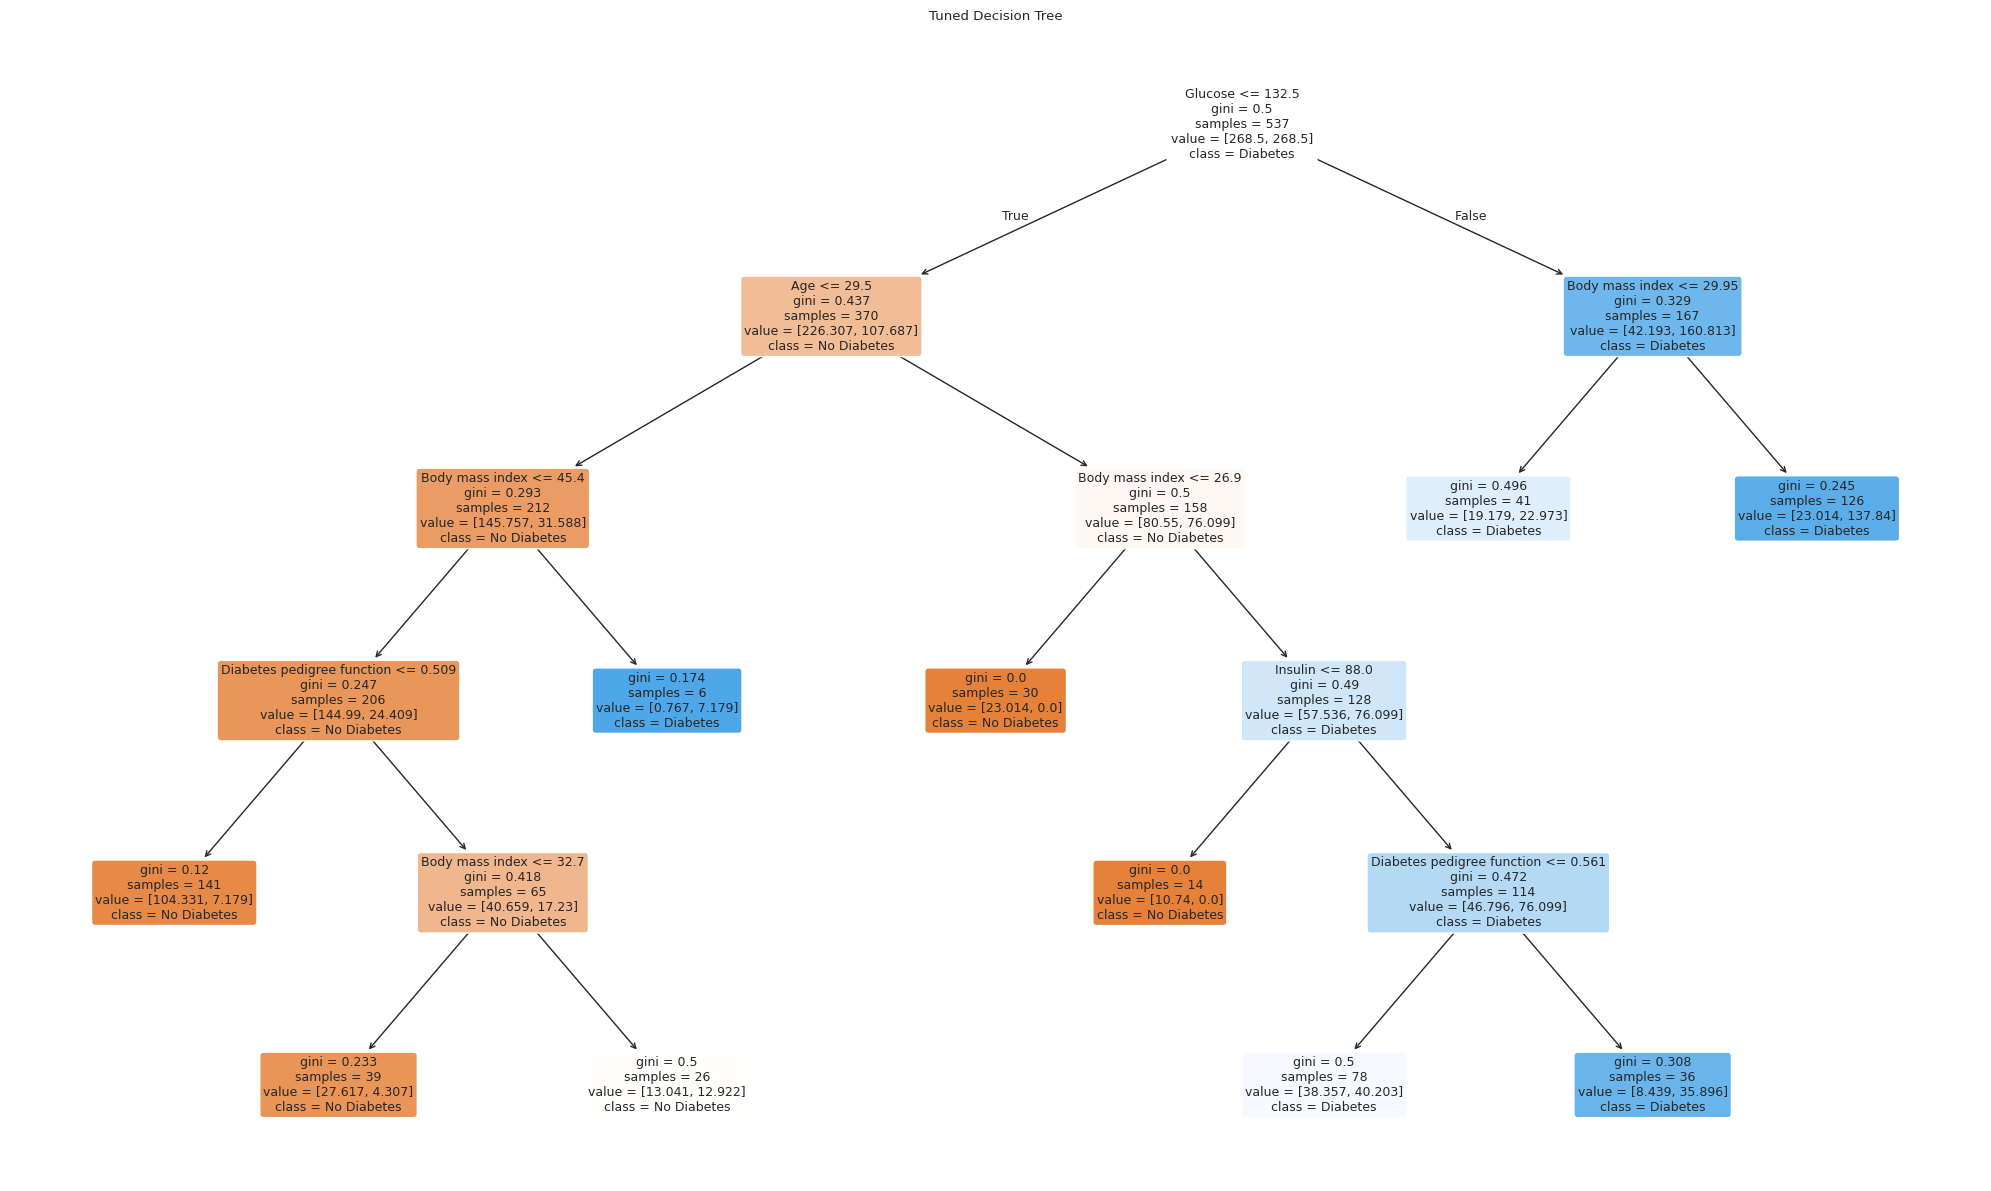

In [57]:
# @title **Show the tuned decision tree**

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

plt.figure(figsize=(20, 12))

plot_tree(
    tree_classifier,
    feature_names=list(feature_names),
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9,
    node_ids=False
)

plt.title("Tuned Decision Tree")
plt.tight_layout()
plt.show()

***Interpretation***

### Interpretation

The visualization shows the structure of the tuned Decision Tree and how the model makes predictions based on different combinations of predictor values. The first split occurs at **Glucose ≤ 132.5**, making Glucose the most important variable at the top of the tree. This is consistent with the earlier exploratory analysis, where Glucose had the strongest association with the diabetes outcome across the Pearson, Spearman, and Phi-K correlation analyses.

The tree then uses other variables, including **Age, Body mass index, Diabetes pedigree function, and Insulin**, to make additional decisions. For example, among observations with Glucose greater than 132.5, the next split is based on BMI. Among observations with lower glucose levels, Age and BMI are used to further separate the outcome groups.

The colors indicate the class that is more dominant within each node. Orange represents No Diabetes, while blue represents Diabetes. Darker colors indicate that a node is more strongly concentrated toward one outcome, while lighter colors indicate greater mixing between the two classes. The `gini` value describes how mixed the classes are within a node, `samples` shows the number of observations reaching the node, and `value` shows the weighted distribution of the two outcome classes.

The tree was limited using the parameters selected during cross-validation, including a maximum depth of 8, a maximum of 10 leaf nodes, and a minimum of 5 observations per leaf. These restrictions help control the complexity of the model and reduce the risk of overfitting. The visualization also makes the Decision Tree easier to interpret because the model's predictions can be followed through a series of decision rules.

It is important to note that the cutoff values shown in the tree are model-generated predictive thresholds and should not be interpreted as clinical diagnostic guidelines. The tree provides a useful visual explanation of how the model uses Glucose and other predictors to distinguish between the two diabetes outcome groups.


In [58]:
# @title **List feature importance from the tuned decision tree**

import pandas as pd

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.reset_index(drop=True).round(3))

,Feature,Importance
0,Glucose,0.464
1,Body mass index,0.265
2,Age,0.131
3,Diabetes pedigree function,0.076
4,Insulin,0.063
5,Skin thickness,0.000
6,Pregnancies,0.000
7,Blood pressure,0.000


***Interpretation***

### Interpretation

The feature importance results show which predictors contributed the most to the tuned Decision Tree's predictions. **Glucose had the highest importance at 0.464**, followed by **Body mass index at 0.265** and **Age at 0.131**. Diabetes pedigree function and Insulin had smaller importance values of **0.076** and **0.063**, respectively. Skin thickness, Pregnancies, and Blood pressure had importance values of **0.000**, meaning they were not used as splitting variables in the final tuned tree.

Glucose being the most important predictor is consistent with the earlier exploratory analysis. Glucose had the strongest association with Outcome across the Pearson, Spearman, and Phi-K correlation analyses, and it was also the first splitting variable in the Decision Tree. BMI and Age were also among the stronger predictors identified earlier, which is reflected in their relatively high feature importance values.

Overall, Glucose, BMI, and Age accounted for approximately **86% of the tree's total feature importance**. This suggests that these variables contributed most to the model's predictions in this dataset. However, feature importance should be interpreted as **predictive contribution rather than causation**. A variable having low or zero importance in this particular tree does not necessarily mean that it has no relationship with diabetes; it means that the tree did not need to use that variable to make its final set of decisions after considering the other predictors.


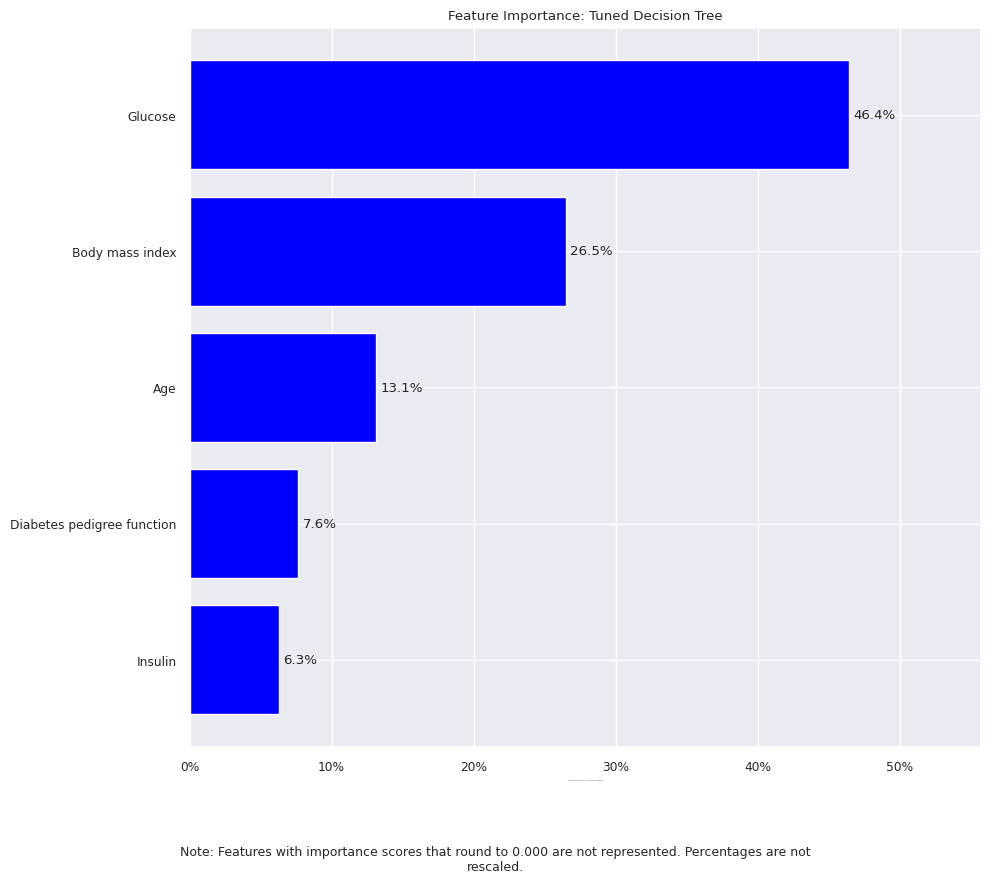

Highest-ranked features in this fitted tree:
- Glucose: 46.4%
- Body mass index: 26.5%
- Age: 13.1%

Excluded features (importance rounds to 0.000): Pregnancies, Blood pressure, Skin thickness

These percentages describe each feature's share of total impurity reduction, not its effect on diabetes risk.


In [59]:
# @title **Visualize feature importance from the tuned decision tree**

import numpy as np
import matplotlib.pyplot as plt
import textwrap
from matplotlib.ticker import PercentFormatter

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()
importances = tree_classifier.feature_importances_

# Exclude scores that round to 0.000 at three decimal places.
included = np.round(importances, 3) > 0
excluded_features = feature_names[~included].tolist()

excluded_note = (
    "Excluded features (importance rounds to 0.000): "
    + ", ".join(excluded_features)
    if excluded_features
    else "No features were excluded."
)

if included.any():
    shown_names = feature_names[included]
    shown_importances = importances[included]
    indices = np.argsort(shown_importances)

    note = textwrap.fill(
        "Note: Features with importance scores that round to 0.000 "
        "are not represented. Percentages are not rescaled.",
        width=100
    )
    note_lines = len(note.splitlines())
    bottom_margin = 0.6 + 0.18 * note_lines
    figure_height = 8 + bottom_margin

    fig, ax = plt.subplots(figsize=(10, figure_height))

    bars = ax.barh(
        range(len(indices)),
        shown_importances[indices],
        color="blue"
    )

    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels(shown_names[indices])
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

    ax.bar_label(
        bars,
        labels=[f"{value:.1%}" for value in shown_importances[indices]],
        padding=3
    )

    ax.set_xlim(0, shown_importances.max() * 1.2)
    ax.set_xlabel("Feature Importance (% of total impurity reduction)")
    ax.set_title("Feature Importance: Tuned Decision Tree")

    fig.text(
        0.5, 0.02,
        note,
        ha="center",
        va="bottom",
        fontsize=9
    )

    plt.tight_layout(
        rect=[0, bottom_margin / figure_height, 1, 1]
    )
    plt.show()

    print("Highest-ranked features in this fitted tree:")
    for index in indices[::-1][:3]:
        print(f"- {shown_names[index]}: {shown_importances[index]:.1%}")

else:
    print("All feature importance scores round to 0.000; no graph displayed.")

print(f"\n{excluded_note}")
print(
    "\nThese percentages describe each feature's share of total "
    "impurity reduction, not its effect on diabetes risk."
)

***Interpretation***

### Interpretation

The feature importance plot provides a visual representation of the predictors used by the tuned Decision Tree. **Glucose had the highest importance at 46.4%**, followed by **Body mass index at 26.5%** and **Age at 13.1%**. Together, these three features accounted for approximately **86% of the total feature importance** in the fitted tree. Diabetes pedigree function and Insulin contributed smaller amounts, while Pregnancies, Blood pressure, and Skin thickness had importance scores that rounded to 0.000 and were therefore excluded from the visualization.

The results are consistent with the earlier exploratory analysis and the structure of the Decision Tree, where Glucose was the first variable used to split the data. The visualization makes it easier to see how much more heavily the tree relied on Glucose compared with the other predictors.

These percentages represent each feature's share of the tree's **total impurity reduction** and should not be interpreted as the percentage effect of a feature on diabetes risk. A feature having low or zero importance in this fitted tree also does not necessarily mean that the variable has no relationship with diabetes; it means that the tree did not rely on that variable when making its final set of decisions.


***Workflow Reflection***


This assignment helped me understand how an automated data analysis and machine learning pipeline moves from raw data to model evaluation. The workflow started with examining the dataset and its descriptive statistics to understand the variables, their distributions, and the outcome variable. This was followed by data cleaning and preprocessing, including identifying values that were technically recorded as zeros but were not realistic measurements for certain clinical variables. These values were converted to missing values so they could be handled appropriately before modeling.

The next part of the workflow focused on understanding the relationships within the data through correlation analyses and visualizations. We used Pearson, Spearman, and Phi-K correlations, along with histograms, boxplots, scatterplots, violin plots, and other visualizations. These steps helped me see that exploratory data analysis (EDA) help identify unusual values, understand distributions, recognize potential relationships between predictors and the outcome, and make better decisions about how the data should be prepared for modeling.

The pipeline then moved into inferential statistics. We used one-sample and independent-samples t-tests, ANOVA, and a chi-square test to examine whether differences or associations observed in the data were statistically significant. This allowed me to better understand the difference between simply observing a pattern in the data and formally testing whether there is evidence of an association or difference.

After the exploratory and statistical analysis, the data was prepared for machine learning. The outcome was checked to make sure it was coded as 0 and 1, and non-predictor columns such as Outcome_label were removed before splitting the data. The data was then divided into training and test sets using stratification so that both sets maintained a similar distribution of the two outcome classes.

The machine learning portion began with Logistic Regression and a Decision Tree. Missing predictor values were handled using median imputation, and standardization was applied to Logistic Regression. An important lesson from this step was that preprocessing should be learned from the training data rather than the entire dataset. This helps prevent data leakage, where information from the test data unintentionally influences the model.

The models were then evaluated using several performance measures, including accuracy, recall, precision, F1 score, and ROC AUC. I learned how to interpret confusion matrices by looking at true positives, true negatives, false positives, and false negatives. This was especially useful for understanding that accuracy alone does not tell the entire story of a classification model. In a health-related prediction problem, the type of error can be just as important as the overall percentage of correct predictions.

Another important part of the workflow was adjusting the Logistic Regression classification cutoff. Instead of automatically using the default 0.50 threshold, the pipeline selected a cutoff of 0.443 using cross-validation and Youden's J statistic. This showed that model performance can depend not only on the model itself, but also on how its predicted probabilities are converted into final classifications.

Finally, the Decision Tree was tuned using GridSearchCV and stratified cross-validation. The tuning process tested different combinations of tree depth, leaf size, number of leaf nodes, and class weights. The final tree was then evaluated on the test set and visualized to better understand how it made predictions. Feature importance showed that Glucose, BMI, and Age contributed the most to the decisions made by the fitted tree.

